# Tutorial: Entendimiento de los datos con PySpark

## Introducción
    ¿Qué aprenderá? 
    En este tutorial aprenderá cómo puede realizar el entendimiento de los datos en el contexto de un proyecto de analítica. A nivel de la metodología ASUM-DM estamos en la fase de entendimiento de datos y en la arquitectura nos encontramos trabajando con el componente de fuentes de datos.

    ¿Qué construirá? 
    En este tutorial realizará la exploración o perfilamiento de un conjunto de datos provenientes de una base de datos relacional, al igual que un análisis de la calidad de los datos utilizando los DataFrames de PySpark. Además, generará las conclusiones requeridas para ser compartidas en reuniones y formalizadas en la documentación del proyecto. Las conclusiones son variadas pero en general podemos decir que siempre deberían incluir una lista de preguntas o aclaraciones para la organización, conclusiones de los datos/problemas de calidad y alternativas para la limpieza. Un entendimiento de datos sin conclusiones no es útil y tampoco es entendible para personas de negocio.
    
    ¿Para qué?
    Antes de realizar cualquier tipo de proyecto de datos es necesario entender los datos con unas tareas de exploración o perfilamiento de datos y de análisis de calidad. Esta fase de la metodología permite determinar si es posible o no realizar el proyecto dada la cantidad y calidad de los datos, el tiempo requerido para su preparación y las diferentes actividades que se requieren para mejorar los datos en caso de requerirse.  
    
    ¿Qué necesita?
    Los siguientes requisitos se encuentran instalados en la máquina virtual asignada a cada estudiante, específicamente en el ambiente de anaconda llamado "Tutoriales". Recuerde que tiene a su disposición el tutorial de conexión a máquinas virtuales en la semana 1 de Coursera
    1. Python 3 con pip instalado
    2. Jupyter Labs
    3. Paquetes: Pyspark (3.2.1), pandas (1.2.1), numpy (1.20.0) y matplotlib (3.3.4)
    Otros:
    1. Controlador Connector J(ya se encuentra configurado)
    2. Acceso a servidor remoto MySQL con base de datos relacional "WWImportersTransactional". Recuerde que tiene a su disposición el tutorial de conexión remoto a Mysql en la semana 1 de Coursera


Continuando con el proyecto de consultoria de Wide World Importers, el primer paso para iniciar la comprensión de los datos es explorar y entender las fuentes de datos disponibles. Note que esto también nos ayuda a comprender mejor la organización.

## Configuración e importe de paquetes
Se utilizará el paquete de pandas profiling para apoyar el análisis estadístico, y se importan los paquetes de python
necesarios

In [3]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions
from pyspark.sql.types import StructType
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql.types import FloatType, StringType, IntegerType, DateType
from pyspark.sql.functions import udf, col, length, isnan, when, count
import pyspark.sql.functions as f
import os 
from datetime import datetime
from pyspark.sql import types as t
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import numpy as np


/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuración del controlador e inicio de sesion Spark

In [4]:
path_jar_driver = os.environ.get('CONNECTOR_J_PATH', '/workspaces/Modelado-de-Datos-y-ETL/.devcontainer/mysql-connector-j-9.3.0.jar')

In [5]:
#Configuración de la sesión
conf=SparkConf() \
    .set('spark.driver.extraClassPath', path_jar_driver)

spark_context = SparkContext(conf=conf)
sql_context = SQLContext(spark_context)
spark = sql_context.sparkSession

Picked up JAVA_TOOL_OPTIONS: -Xss512k -XX:+UseContainerSupport
Picked up JAVA_TOOL_OPTIONS: -Xss512k -XX:+UseContainerSupport
26/06/17 02:10:09 WARN Utils: Your hostname, codespaces-607d39 resolves to a loopback address: 127.0.0.1; using 10.0.1.38 instead (on interface eth0)
26/06/17 02:10:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/17 02:10:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
/home/vscode/.local/lib/python3.11/site-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [6]:
db_connection_string = 'jdbc:mysql://157.253.236.120:8080/WWImportersTransactional'
db_user = 'DB_202613_c_cantini'
db_psswd = '201923481'

PATH='./'

## Perfilamiento de los datos
El perfilamiento se basa en varios aspectos: **entendimiento general** de los datos compartidos, validación de **reglas de negocio**, **análisis descriptivo** utilizando estadística descriptiva y diagramas para la visualización de los datos y **análisis de calidad**. El primero hace referencia a tener una comprensiòn global antes de entrar en los detalles, la segunda sobre las reglas, corresponden a especificaciones dadas por el negocio en relación con los datos, un ejemplo de regla de negocio dada es: "Todo producto de la canasta familiar debe tener un precio de IVA equivalente a 19%", dada esta regla de negocio, se debe revisar en los datos suministrados que no hayan valores de IVA menores a 19%. En el tercer aspecto, relacionado con el análisis descriptivo, se revisan estadísticas: mínimo, máximo, media, mediana, distribuciones de los datos, valores nulos, cardinalidad con el fin de comprender en mayor nivel de profundidad los datos compartidos.


### Información dada por la organización relacionada con los datos
El grupo de consultores de analitica descriptiva de Wide World Importers asegura que las tablas Grupo de compras, Ciudades, Colores, Paises, Clientes, Categorias de clientes, Paquetes, Estados y provincias, Productos y Personas ya fueron perfiladas y corregidos; sin embargo le recomiendan revisar el diccionario suministrado dado que todas las tablas serán utilizadas en futuros requerimientos (tutoriales y ejercicios) que lo encuentra [aqui](./Diccionario%20WWImporters.xlsx). Si tienen alguna duda relacionada con estas tablas deben incluirla en las preguntas o aclaraciones que le entreguen a la organización como parte del resultado de esta fase de entendimiento.

En este punto de la consultorìa, nuestra responsabilidad es analizar las tablas ordenes y detalles de ordenes, relacionadas con al proceso de ordenes de compra de productos. Con respecto a esas fuentes nos comentan lo siguiente:

- La tasa de impuesto es de 10% o 15%
- Son 74.179 órdenes detalladas en 57.981 lineas de detalle de órdenes realizadas desde 2013
- El formato de fechas manejado es YYYY-MM-DD HH:MM:SS si tienen hora, minutos y segundos. De lo contrario el formato es YYYY-MM-DD


### Conexión a fuente de datos y acceso a los datos

#### Conexión a fuente de datos
A continuación encuentra las funciones para conectarse a la fuente de datos (archivo csv o base de datos) y retornar un dataframe que es el que se utilizará posteriormente para manipular los datos.

In [7]:
def obtener_dataframe_de_bd(db_connection_string, sql, db_user, db_psswd):
    df_bd = spark.read.format('jdbc')\
        .option('url', db_connection_string) \
        .option('dbtable', sql) \
        .option('user', db_user) \
        .option('password', db_psswd) \
        .option('driver', 'com.mysql.cj.jdbc.Driver') \
        .load()
    return df_bd

#### Cargue de datos
Para consultar desde la base de datos se puede acceder directamente a la tabla dado su nombre o se puede especificar la sentencia SQL de un "SELECT" completo para traer la información total o parcial de la tabla que se requiere. A continuación un ejemplo de cada uno de estos usos. 
Acceso directo para el caso de órdenes y acceso con sentencia SQL para el caso de detallesOrdenes.

In [8]:
sql_ordenes = 'WWImportersTransactional.OrdenesCopia'

In [9]:
sql_detallesOrdenes = '''(SELECT 
        Detalle_orden_ID, 
        ID_de_pedido, 
        ID_Producto, 
        Descripcion, 
        ID_Tipo_Paquete, 
        Cantidad, 
        Precio_unitario, 
        Tasa_de_impuesto, 
        Cantidad_seleccionada, 
        Seleccion_completada_cuando 
        FROM WWImportersTransactional.DetallesOrdenesCopia) AS Compatible'''

In [10]:
#Se cargan los dataframes desde la base de datos
ordenes = obtener_dataframe_de_bd(db_connection_string, sql_ordenes, db_user, db_psswd)
detallesOrdenes = obtener_dataframe_de_bd(db_connection_string, sql_detallesOrdenes, db_user, db_psswd)

### Entendimiento general de datos

Para ver una muestra de los datos, utilice el comando <i>show</i> ingresando el número de filas que quiere ver

In [11]:
ordenes.show(5)

+------------+-------------+--------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-------------------------------------------+-----------+------------------------+--------------------+---------------------------+
|ID_de_pedido|ID_de_cliente|ID_de_vendedor|Seleccionado_por_ID_de_persona|ID_de_persona_de_contacto|ID_de_pedido_pendiente|Fecha_de_pedido|Fecha_de_entrega_esperada|Numero_de_pedido_de_compra_del_cliente|Pedido_pendiente_de_suministro_insuficiente|Comentarios|Instrucciones_de_entrega|Comentarios_internos|Seleccion_completada_cuando|
+------------+-------------+--------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-------------------------------------------+-----------+------------------------+--------------------+------------------------

In [12]:
detallesOrdenes.show(5)

+----------------+------------+-----------+--------------------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|Detalle_orden_ID|ID_de_pedido|ID_Producto|         Descripcion|ID_Tipo_Paquete|Cantidad|Precio_unitario|Tasa_de_impuesto|Cantidad_seleccionada|Seleccion_completada_cuando|
+----------------+------------+-----------+--------------------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|          206857|       65697|        205|Tape dispenser (B...|              7|      60|             32|              15|                   60|        2016-01-27 11:00:00|
|          206858|       65698|         45|Developer joke mu...|              7|       3|             13|              15|                    3|        2016-01-27 11:00:00|
|          206859|       65698|         72|Ride on toy sedan...|              7|       3|            230|              15|             

Como puede observar en la tabla de ordenes tenemos información **relacionada con el cliente, el empleado y con la órden**. La información del cliente es su identificador <i>ID_de_cliente</i>, el identificador de la persona que eligió la órden <i>eleccionado_por_ID_de_persona</i>, el identificador de la persona de contacto <i>ID_de_persona_de_contacto</i>, el <i>Número_de_pedido_de_compra_del_cliente</i>. La información del empleado es su identificador <i>ID_de_vendedor</i>. La información de la órden es: el identificador de la órden <i>ID_de_pedido</i>, el identificador que indica si es un pedido pendiente <i>ID_de_pedido_pendiente</i>, la fecha en la que se realizó el pedido <i>Fecha_de_pedido</i>, la fecha de entrega esperada del pedido <i>Fecha_de_entrega_esperada</i> y <i>Pedido_pendiente_de_suministro_insuficiente</i> que indica si es un pedido pendiente o no.
El esquema de un DataFrame incluye los nombres de las columnas asi como el tipo de dato. Recuerde que tipo de dato (e.g., booleano, caracteres, enteros, flotantes, colecciones) es diferente a tipo de variable (numérica y categórica).

In [13]:
ordenes.schema

StructType([StructField('ID_de_pedido', IntegerType(), True), StructField('ID_de_cliente', IntegerType(), True), StructField('ID_de_vendedor', IntegerType(), True), StructField('Seleccionado_por_ID_de_persona', IntegerType(), True), StructField('ID_de_persona_de_contacto', IntegerType(), True), StructField('ID_de_pedido_pendiente', IntegerType(), True), StructField('Fecha_de_pedido', StringType(), True), StructField('Fecha_de_entrega_esperada', StringType(), True), StructField('Numero_de_pedido_de_compra_del_cliente', StringType(), True), StructField('Pedido_pendiente_de_suministro_insuficiente', BooleanType(), True), StructField('Comentarios', StringType(), True), StructField('Instrucciones_de_entrega', StringType(), True), StructField('Comentarios_internos', StringType(), True), StructField('Seleccion_completada_cuando', TimestampType(), True)])

Por otra parte, en los detalles de ordenes se tiene **información del pedido y del producto**. Del pedido se tiene el identificador del detalle <i>Detalle_orden_ID</i>, el identificador de la orden a la que está relacionado cada detalle <i>ID_de_pedido</i>, la <i>Cantidad_seleccionada</i> del producto para la orden, la fecha de selección <i>Seleccion_completada_cuando</i>. Del producto tenemos el <i>ID_Producto</i>, su <i>Descripcion</i>, el tipo de paquete <i>ID_Tipo_Paquete</i> (Ej. 1.Bolsa, 4. Caja), la <i>Cantidad</i>, el <i>Precio_unitario</i>, y la <i>Tasa_impuesto</i> asociada a ese producto. Una primera aclaración a solicitar por parte del negocio es cuál es la diferencia entre cantidad y cantidad seleccionada

In [14]:
detallesOrdenes.schema

StructType([StructField('Detalle_orden_ID', IntegerType(), True), StructField('ID_de_pedido', IntegerType(), True), StructField('ID_Producto', IntegerType(), True), StructField('Descripcion', StringType(), True), StructField('ID_Tipo_Paquete', IntegerType(), True), StructField('Cantidad', IntegerType(), True), StructField('Precio_unitario', DecimalType(10,0), True), StructField('Tasa_de_impuesto', DecimalType(10,0), True), StructField('Cantidad_seleccionada', IntegerType(), True), StructField('Seleccion_completada_cuando', TimestampType(), True)])

**¿Qué es una fila de cada fuente compartida?**
Con estos análisis podemos concluir que una fila de órdenes representa la órden realizada por un cliente y atendida por un empleado. Mientras que el detalle de órden coincide con su nombre y contiene el detalle de cada producto solicitado en una órden.

Una vez entendida en términos generales la estructura de los datos, es necesario conocer la cantidad de datos disponibles, esto se hace con count() y con columns, que retornan el número de filas y número de columnas respectivamente.

In [15]:
print((detallesOrdenes.count(), len(detallesOrdenes.columns)),(ordenes.count(), len(ordenes.columns)))

(58320, 10) (88258, 14)


**¿Cuantos datos nos compartieron para el proyecto?**
En total tenemos 58.320 órdenes y 88.258 detalles de orden y tenemos en total 24 variables a revisar de las cuales 8 son nùmericas asociadas a las órdenes, dos son de tipo fecha y las demás son cadenas de caracteres.

### Revisión de reglas de negocio 

Primero se confirman las reglas proporcionadas por el negocio, la primera que asegura que la tasa de impuesto es de 10% o 15% vemos que no es correcta pues al seleccionar esa columna e indicar que queremos ver los valores distintos que puede tomar se observa únicamente el valor 15

In [16]:
detallesOrdenes.select("Tasa_de_impuesto").distinct().show()

+----------------+
|Tasa_de_impuesto|
+----------------+
|              15|
+----------------+



Si se quiere saber cuántos registros hay por cada valor posible, existen varias formas de hacerlo, en la siguiente celda se muestra cómo iterar sobre los valores resultado de una consulta y cómo filtrar el número de registros para cada valor usando filter y select where, también se da un ejemplo de uso de group by y agregaciones

Pyspark tiene funcionalidades de los DataFrames que permiten explorar los datos por medio de agregaciones y estas funcionan similar a como se usan en SQL

Primero, se debe agrupar sobre una columna con el método <i>groupBy</i> y después se pueden realizar agregaciones sobre otras columnas con el método <i>agg</i>. La sintaxis es la siguiente: 
 ``` 
    DataFrame.groupBy('COLUMN NAME').agg({'COLUMN NAME 1': 'mean', 'COLUMN NAME 2': 'count', 'COLUMN NAME 3': 'max'})
  ``` 

En cualquiera de los 3 casos se observa que el resultado es el mismo

In [17]:
for row in detallesOrdenes.select('Tasa_de_impuesto').distinct().collect(): 
    texto = 'número de registros con '+str(row.Tasa_de_impuesto)+ '% de tasa de impuesto: '
    opc1 ="--Usando filter--"
    print(texto+opc1+str(detallesOrdenes.filter(col('Tasa_de_impuesto')==row.Tasa_de_impuesto).count()))
    
    opc2 ="--Usando Select where--"
    print(texto+opc2+str(detallesOrdenes.select().where(col('Tasa_de_impuesto')==row.Tasa_de_impuesto).count()))
    opc3 ="--Usando group by--"
detallesOrdenes.groupBy("Tasa_de_impuesto").count().show()

número de registros con 15% de tasa de impuesto: --Usando filter--58320


número de registros con 15% de tasa de impuesto: --Usando Select where--58320


+----------------+-----+
|Tasa_de_impuesto|count|
+----------------+-----+
|              15|58320|
+----------------+-----+



La conclusión es entonces que la regla no es completamente cierta, pues en los datos no hay ningun registro con tasa_de_impuesto de 10%, es necesario pedir aclaraciones al negocio en relación a este descubrimiento. La segunda regla de negocio implica conocer el número de registros y de variables que los describen, es decir, el número de filas y columnas del DataFrame respectivamente, esto se logra usando count() y columns

In [18]:
print((detallesOrdenes.count(), len(detallesOrdenes.columns)),(ordenes.count(), len(ordenes.columns)))

(58320, 10) (88258, 14)


Podemos concluir que esta regla de negocio no es cierta dado que el número de registros no parece coincidir con el número dado por el negocio, una primera intuición nos dice que podrían haber registros duplicados y si existen hay que reportarlos y eliminarlos en la fase de preparación de los datos. Esta es la primera conclusión del análisis de entendimiento de datos.

In [19]:
detallesOrdenes.distinct().count(), ordenes.distinct().count() 

(58239, 74179)

Como pueden ver hay 58.239 detalles de orden y 74.179 ordenes únicas. Es decir que sabemos que hay 14.079 ordenes completamente repetidas, pero entonces ¿por qué el número de detalles de orden que hay en los datos no coincide con el dado por la organización? 

La respuesta es que no basta solo con revisar si hay registros idénticos, puede que hayan registros con columnas identificadoras o lo que conoceriamos como las llaves primarias repetidas pero con diferentes valores en los otros atributos. Esto se da principalmente cuando las bases de datos están mal construidas, aunque hay casos en los cuales tiene sentido. En cualquier caso es nuestra responsabilidad preveer estos escenarios, por ende se revisan los datos por la llave primaria de esta tabla:

In [20]:
detallesOrdenes.select(col('Detalle_orden_ID')).distinct().count()

57981

De esta manera vemos que hay una diferencia de 258 registros cuyo identificador es el mismo y vemos que el número de identificadores únicos coincide con el número dado por el negocio, la segunda conclusión es entonces que tenemos 258 registros que representan el mismo detalle de orden pero con valores distintos.

Lo siguiente es verificar las fechas en los datos, nos dicen que son ordenes desde 2013 por lo que se revisa la fecha mínima del atributo Fecha_de_pedido, como se observa la fecha mínima es de 2014 enero 1, esto nos indica que la regla de negocio no es correcta o faltan datos, esta es la tercera conclusión

In [21]:
ordenes.agg({"Fecha_de_pedido": "min"}).show()

+--------------------+
|min(Fecha_de_pedido)|
+--------------------+
|          2014-01-01|
+--------------------+



 ``` 
Como ve en el comando anterior las agregaciones también se pueden realizar sin un groupBy.
 ``` 

La siguiente regla nos indica que es necesario revisar el formato de las fechas YYYY-MM-DD HH:MM:SS, un ejemplo es el atributo <i>Fecha_de_pedido</i>. Para esto vamos a hacer uso de expresiones regulares, que son patrones de búsqueda, en este caso queremos 4 dígitos entre 0 y 9 que indican el año seguido del símbolo - luego tenemos un número de 2 dígitos que puede empezar con 0 seguido de un número entre 1 y 9 (meses 01 hasta 09) o 1 seguido de 1 o 2 (meses 11 o 12), sigue otro -, y terminamos con un número de 2 dígitos que van desde el día 01 hasta el 31, se usa rlike smilar a LIKE de SQL

In [22]:
regex = "[0-2]\d{3}-(0[1-9]|1[0-2])-(0[1-9]|[1-2][0-9]|3[0-1])"
cumplenFormato = ordenes.filter(ordenes["Fecha_de_pedido"].rlike(regex))
print("Número total de ordenes: "+str(ordenes.count())+", número de ordenes con formato correcto: "+str(cumplenFormato.count()))

Número total de ordenes: 88258, número de ordenes con formato correcto: 68223


Para ver los registros que no cumplen con el formato podemos negar la condición del filtro con el símbolo ~ al principio:

In [23]:
noCumplenFormato = ordenes.filter(~ordenes["Fecha_de_pedido"].rlike(regex))
noCumplenFormato.count(), noCumplenFormato.select(col("Fecha_de_pedido")).show()

+---------------+
|Fecha_de_pedido|
+---------------+
|    Mar 05,2015|
|    Mar 24,2015|
|    Mar 18,2014|
|    Apr 21,2015|
|    Nov 11,2014|
|    Oct 16,2014|
|    May 04,2015|
|    Nov 24,2014|
|    May 07,2015|
|    Sep 10,2014|
|    Nov 03,2015|
|    Dec 19,2014|
|    Apr 27,2016|
|    Apr 28,2016|
|    Sep 23,2014|
|    Oct 02,2015|
|    Jun 11,2014|
|    Feb 17,2014|
|    Aug 14,2015|
|    Dec 25,2015|
+---------------+
only showing top 20 rows



(20035, None)

Concluimos entonces, que hay 20.035 registros cuya fecha no cumple con el formato especificado. Sin embargo, los valores que son diferentes parecen serlo solo porque varia el formato, este tipo de casos pueden ser solucionados fácilmente por lo que una notificación al negocio sería con caracter informativo más que para solicitar una aclaración de su parte.

Para facilitar los análisis y evitar inconsistencias o conclusiones erradas vamos a estandarizar los datos, en este caso las fechas. Sin embargo, esta actividad puede hacerse sobre formatos de números, texto entre otras. 

Algo que se debe tener en cuenta en el perfilamiento de reglas de negocio es que dichas reglas pueden estar incompletas, por ende se recomienda tener especial cuidado con las columnas tipo caracter o string dado que suelen ser pasadas por alto en el análisis estadistico, un ejemplo es la columna **Descripcion**, al ser una columna de descripción del producto se espera que tenga un cierto número de caracteres. Sin embargo haciendo la validación vemos que algunas descripciones son textos incompletos como "a". Este podría llegar a ser un problema a futuro por lo que se decide notificar a la organización.

In [24]:
detallesOrdenes.where(length(col("Descripcion")) <= 10).show()

+----------------+------------+-----------+-----------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|Detalle_orden_ID|ID_de_pedido|ID_Producto|Descripcion|ID_Tipo_Paquete|Cantidad|Precio_unitario|Tasa_de_impuesto|Cantidad_seleccionada|Seleccion_completada_cuando|
+----------------+------------+-----------+-----------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|          206862|       65698|         10|          a|              7|       5|             32|              15|                    5|        2016-01-27 11:00:00|
|          206874|       65701|         47|          a|              7|       5|             13|              15|                    5|        2016-01-27 11:00:00|
|          206909|       65711|         37|          a|              7|       5|             13|              15|                    5|        2016-01-27 11:00:00|
|          20691

### Análisis descriptivo
Una vez cubierto lo básico de reglas de negocio, pasamos a perfilamiento estadístico. Para ver estadisticos generales como conteo, mínimo, máximo, desviación estandar y percentiles utilice summary()

In [25]:
ordenes.summary().show()

26/06/17 02:11:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+-----------------+-----------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-----------+------------------------+--------------------+
|summary|     ID_de_pedido|    ID_de_cliente|   ID_de_vendedor|Seleccionado_por_ID_de_persona|ID_de_persona_de_contacto|ID_de_pedido_pendiente|Fecha_de_pedido|Fecha_de_entrega_esperada|Numero_de_pedido_de_compra_del_cliente|Comentarios|Instrucciones_de_entrega|Comentarios_internos|
+-------+-----------------+-----------------+-----------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-----------+------------------------+--------------------+
|  count|            88258|            88258|            88258|                         74688|                    88258|                  9223|        

En las estadísticas anteriores vemos que las columnas Comentarios, Instrucciones_de_entrega y Comentarios_internos tienen un conteo igual a 0, es decir son columnas vacías por lo que s epueden eliminar, también observamos el calculo de la media para las columnas ID, esto se hace automatico pues son columnas cuyo tipo de dato es numerico, sin embargo estas no son variables numericas por lo cual calcular y/o analizar la media no tiene sentido. La lógica es similar para los otros estadísticos, aunque podemos decir que los ID's de pedido van desde el número 19443 hasta el 73595 por ejemplo

In [26]:
detallesOrdenes.summary().show()

+-------+------------------+------------------+------------------+--------------------+---------------+------------------+-----------------+----------------+---------------------+
|summary|  Detalle_orden_ID|      ID_de_pedido|       ID_Producto|         Descripcion|ID_Tipo_Paquete|          Cantidad|  Precio_unitario|Tasa_de_impuesto|Cantidad_seleccionada|
+-------+------------------+------------------+------------------+--------------------+---------------+------------------+-----------------+----------------+---------------------+
|  count|             58320|             58320|             58320|               58320|          58320|             58320|            57337|           58320|                58320|
|   mean|152909.77184499314| 91440.73607681756|111.83144718792867|                NULL|            7.0|213.03914609053498|          44.5468|         15.0000|    39.74422153635117|
| stddev| 72929.99490225241|29085.094720342793| 64.32670239320214|                NULL|            0

En las estadíticas de orden podemos observar que el valor promedio de precio unitario es 44.54, la cantidad promedio es 213 unidades y el promedio de cantidad seleccionada es 39.74

En cuanto a la desviación estandar vemos que, por ejemplo, el precio unitario puede variar en más o menos 139.45. El valor mínimo de cantidad es 1 y el máximo es 10'000.000, de cantidad seleccionada el mínimo es 0 y el máximo 360 y de precio unitario el mínimo es 1 y el máximo 1899. Vemos por ejemplo que el valor máximo de Cantidad indica valores anómalos o extremos, pues en su percentil 75% el valor máximo era 70, es decir, para el 75% de los datos, el valor de Cantidad no superaba el 70. Observamos que la columna ID_Tipo_Paquete solo toma el valor 7, que podría ser o no un error, se notifica al negocio.

Otras formas de observar distribución o estadísticos son las graficas, de barras, de dispersión, diagramas de caja, entre otros. Por ejemplo tenemos los siguientes diagramas de caja donde se observa claramente que tenemos un valor extremo en la variable cantidad (primer grafico) y donde podemos ver los valores extremos o bigotes que determinan el punto de separación entre valores atípicos y normales, los valores atipicos, los cuartiles entre otros

{'whiskers': [<matplotlib.lines.Line2D at 0x7b722dab9550>,
 'caps': [<matplotlib.lines.Line2D at 0x7b722dabaa90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b71f1230990>],
 'medians': [<matplotlib.lines.Line2D at 0x7b722dabbe90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b71edee2250>],
 'means': []}

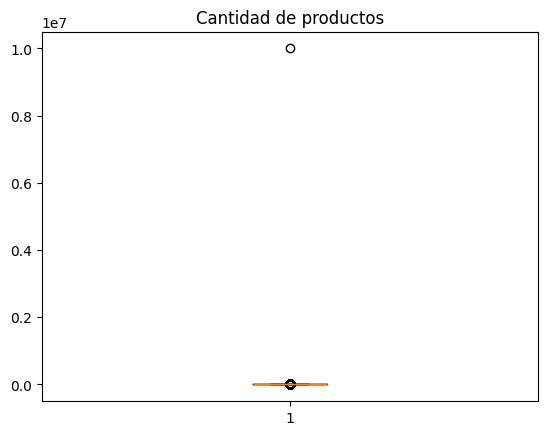

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots()
ax1.set_title('Cantidad de productos')
ax1.boxplot(np.array(detallesOrdenes.select('Cantidad').collect()))

{'whiskers': [<matplotlib.lines.Line2D at 0x7b71edfaf9d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7b71fff51790>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b720013b5d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7b71fff52f50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b71fff53b10>],
 'means': []}

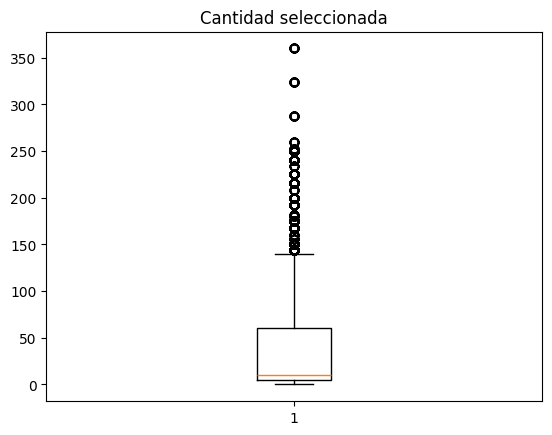

In [28]:
fig1, ax1 = plt.subplots()
ax1.set_title('Cantidad seleccionada')

my_list = [float(i) for i in detallesOrdenes.select(f.collect_list('Cantidad_seleccionada')).first()[0]]
ax1.boxplot(my_list)

El análisis anterior es muy útil para variables de tipo numérico, sin embargo es incompleto para las variables de tipo caracter o las variables categoricas, por ende es necesario implementar nuestro propio código par obtener estadisticos como la moda y la mediana. A continuación obtenemos la moda para la variable Descripcion:

In [29]:
detallesOrdenes.groupby("Descripcion").count().orderBy("count", ascending=False).show(5)

+--------------------+-----+
|         Descripcion|count|
+--------------------+-----+
|                   a| 3225|
|Halloween skull m...|  306|
|Large  replacemen...|  305|
|"The Gu" red shir...|  303|
|"The Gu" red shir...|  296|
+--------------------+-----+
only showing top 5 rows



## Análisis de calidad de datos
La calidad de los datos consiste en validar la idoneidad de los datos analizando varias dimensiones, entre las cuales resaltamos:
- Completitud: Datos que no existen o no se conocen
- Unicidad (Duplicidad): Datos que son idénticos en diferentes registros o registros con valores idénticos en atributos en los que no debería ocurrir
- Consistencia: Esta medida se define por la validez o integridad del dato, en la definición de su estructura, al interior de una fila o entre diferentes filas de la misma fuente o de diferentes fuentes. El manejo de unidades en los datos y el significado del dato son generadores de inconsistencias.
- Validez: a nivel de formato y de sentido de los datos más alla de sus valores

Para asegurar una calidad mínima de los datos en estas dimensiones hay que entender su origen y posteriormente realizar un proceso de validación de cada una de las dimensiones de perfilamiento que llevará a un entendimiento de los datos disponibles.


A continuación se definen dos funciones, la primera cuenta los valores vacios por columna de dataframe, la segunda retorna un diccionario de columnas con cardinalidad superior al 50%

Te invito a revisar los recursos de calidad de datos que hemos visto en el curso, a continuacion ejemplos daremos algunos ejemplos por cada dimensión para el caso del tutorial

### Unicidad y validez

La unicidad se revisó en la segunda regla de negocio y la validez se reviso en el perfilamiento general, en la regla de negocio 3 y en el análisis de la descripción al final de la sección de revisión de reglas de negocio

### Completitud y validez

In [30]:
def contar_vacios(df):
    resultados = []
    for c in df.columns:
        vacios = df.filter(df[c].isNull()).count()
        if vacios!=0:
            print('número de vacíos para columna '+c+': '+str( vacios ))
            resultados.append(vacios)
    return resultados

def cardinalidad(df):
    resultado = {}
    for c in df.columns:
        cardinalidad = df.select(col(c)).distinct().count()
        if cardinalidad>=df.count()*0.5:
            resultado[c] = cardinalidad
    return resultado

In [31]:
columnas_vacias_ordenes = contar_vacios(ordenes)
print('detalles de ordenes: ')
columnas_vacias_detalles = contar_vacios(detallesOrdenes)

número de vacíos para columna Seleccionado_por_ID_de_persona: 13570


número de vacíos para columna ID_de_pedido_pendiente: 79035


número de vacíos para columna Comentarios: 88258


número de vacíos para columna Instrucciones_de_entrega: 88258


número de vacíos para columna Comentarios_internos: 88258


número de vacíos para columna Seleccion_completada_cuando: 4347
detalles de ordenes: 
número de vacíos para columna Precio_unitario: 983
número de vacíos para columna Seleccion_completada_cuando: 982


In [32]:
columnas_alta_cardinalidad_ordenes = cardinalidad(ordenes)
columnas_alta_cardinalidad_detalles = cardinalidad(detallesOrdenes)
columnas_alta_cardinalidad_ordenes, columnas_alta_cardinalidad_detalles

({'ID_de_pedido': 54145}, {'Detalle_orden_ID': 57981, 'ID_de_pedido': 38742})

Como podemos observar para las ordenes las columnas Seleccionado_por_ID_de_persona tiene 13750 vacios, ID_de_pedido_pendiente: 79035, Comentarios: 88258, Instrucciones_de_entrega: 88258, Comentarios_internos: 88258, Seleccion_completada_cuando: 4347, mientras que para los detalles de ordenes tenemos que las columnas con vacios son Precio_unitario: 983 y Seleccion_completada_cuando: 982. 

Respecto a cardinalidad, solo la columna Detalle_orden_ID tiene una cardinalidad superior al 50%.

### Consistencia
A nivel de consistencia algunos ejemplos de revisión son precios negativos, productos que aparecen en las ordenes pero que no esten registrados en la tabla de produtos. En nuestro caso vamos a verificar que todas las ordenes tengan detalle de orden y viceversa

In [33]:
#consistencia: revisar genially: definicion de consistencia
ids_ordenes = set([x.ID_de_pedido for x in ordenes.select('ID_de_pedido').collect()])
ids_detalles = set([x.ID_de_pedido for x in detallesOrdenes.select('ID_de_pedido').collect()])

len(ids_ordenes-ids_detalles), len(ids_detalles-ids_ordenes)

(44359, 28956)

Como se puede observar hay una diferencia de 44.359 ordenes que no tienen detalles y hay 28.956 detalles que no tienen orden. Ninguno de los casos tiene sentido en el contexto de WideWorldImporters. Esta inconsistencia se notifica al negocio dado que no hay forma de conocer cuáles son los registros que pueden tener ids que no existen

## Herramientas para facilitar el entendimiento de datos

Algunas de las estadísticas antes desarrolladas pueden obtenerse por medio de herramientas como Pandas Profiling una herramienta muy útil, <b><i>Pero no perfecta ni completa</i></b>, es Pandas profiling que dado un conjunto de datos, nos muestra histogramas, estadísticas etc. A continuación guardamos el reporte en html

In [34]:
reporte = ProfileReport(ordenes.toPandas())
reporte.to_file(PATH+"reporte_prefilamiento.html")

Summarize dataset:  26%|██▋       | 5/19 [00:00<00:00, 23.09it/s, Describe variable:ID_de_pedido_pendiente]        /home/vscode/.local/lib/python3.11/site-packages/ydata_profiling/model/pandas/summary_pandas.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series = series.fillna(np.nan)
Summarize dataset:  37%|███▋      | 7/19 [00:00<00:00, 18.03it/s, Describe variable:Comentarios]                                /home/vscode/.local/lib/python3.11/site-packages/ydata_profiling/model/pandas/summary_pandas.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', Tru

Lo primero que hay que notar es que hay 3 secciones principales. La primera es un resumen, la segunda es un análisis por cada variable y luego tenemos interacciones y correlaciones entre variables. 

Seccion general del reporte:
1. Tenemos 14 variables y 88.258 registros (es decir, ordenes), de las cuales 7 son numericas, 2 categoricas, 1 booleana, 1 datetime y 3 no soportadas (la herramienta entiende tipo de variable como tipo de dato, asi que la información que nos da no es necesariamente correcta en este aspecto).

2. En los datos hay 29.3% de datos vacíos, (conclusión)

3. El archivo ocupa en memoria 7.5 MB

4. No hay registros duplicados

Sección de variables del reporte:

5. Note que para cada variable nos dan estadisticos como la media, mínimo y máximo asi como un histograma de distribución de la variable, para nuestros datos no observamos nada por fuera de lo comun. (Como valores extremos)

6. La variable ID_de_pedido tiene 61.3% de valores distintos, es decir, es una variable con alta cardinalidad. Este tipo de variables no aportan a las relaciones entre filas o columnas, por lo que suelen no ser útiles a la hora de hacer análitica.

7. La variable ID_cliente tiene solo el 0,8% de valores distintos, es decir que las ordenes que tenemos parecen ser de pocos clientes, pero que podrían ser recurrentes o fieles

8. Hay 10 empleados en los datos de ordenes

9. Seleccionado_por_ID_persona tiene 15,4% de datos vacíos, no es muy alto pero podríamos eliminarla si no es importante. Preguntar al negocio

10. ID_de_pedido_pendiente tiene un porcentaje de 89,5% de valores vacíos, es casi constante y las columnas constantes no aportan a los análisis, preguntar al negocio si hay algún inconveniente en borrar esta columna

11. Hay 1512 Fecha_de_pedido distintos, siendo el 3 de febrero del 2015 una de las fechas con más número de ordenes

12. Fecha_de_entrega_esperada y Seleccion_completada_cuando tienen alta cardinalidad

Sección de interacciones y correlaciones:

Parecen haber columnas con correlaciones(Spearman) iguales a 1, esto significa que ambas columnas representan la misma información, idealmente no queremos columnas "repetidas", un ejemplo es ID_cliente y ID_de_persona_de_contacto, decidimos preguntarle al negocio si es necesario mantener ambas columnas

<b>Cabe aclarar que un pandas profiling sin interpretación no es suficiente como análisis para realizar el entendimiento de los datos.

Así mismo, recuerde que si es necesario, se debe utilizar otra herramienta (código, visualizaciones, etc) para poder completar el análisis estadístico.</b>

### Algunas gráficas utiles: Diagrama de caja, dispersion, histogramas para entender las distribuciones de las variables

Generalmente las gráficas se emplean para entender la distribución de cada variable, también sirven para visualizar la relación entre 2 o más variables

Algunas gráficas útiles son los histogramas, disepersión, diagramas de caja. Hay varias maneras de implementarlos, con paquetes como matplotlib o pandas, con funciones propias de pyspark, etc, a continuacón mostramos cómo hacerlo a travez de pandas

array([[<Axes: title={'center': 'Cantidad_seleccionada'}>]], dtype=object)

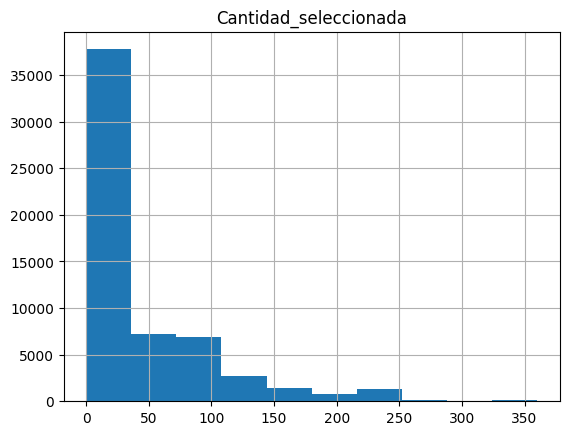

In [35]:
#para valores extremos(subir a calidad)
detallesOrdenes.toPandas().hist(column='Cantidad_seleccionada')

In [36]:
cantidades = detallesOrdenes.groupby("Cantidad").count().orderBy("count", ascending=False)

Como se puede observar, el método retorna un dataframe, que vamos a usar para obtener dos arreglos, uno con el rango de cada una de las barras y otro con la cantidad de registros por rango. Se puede usar Matplotlib para graficar esta información:

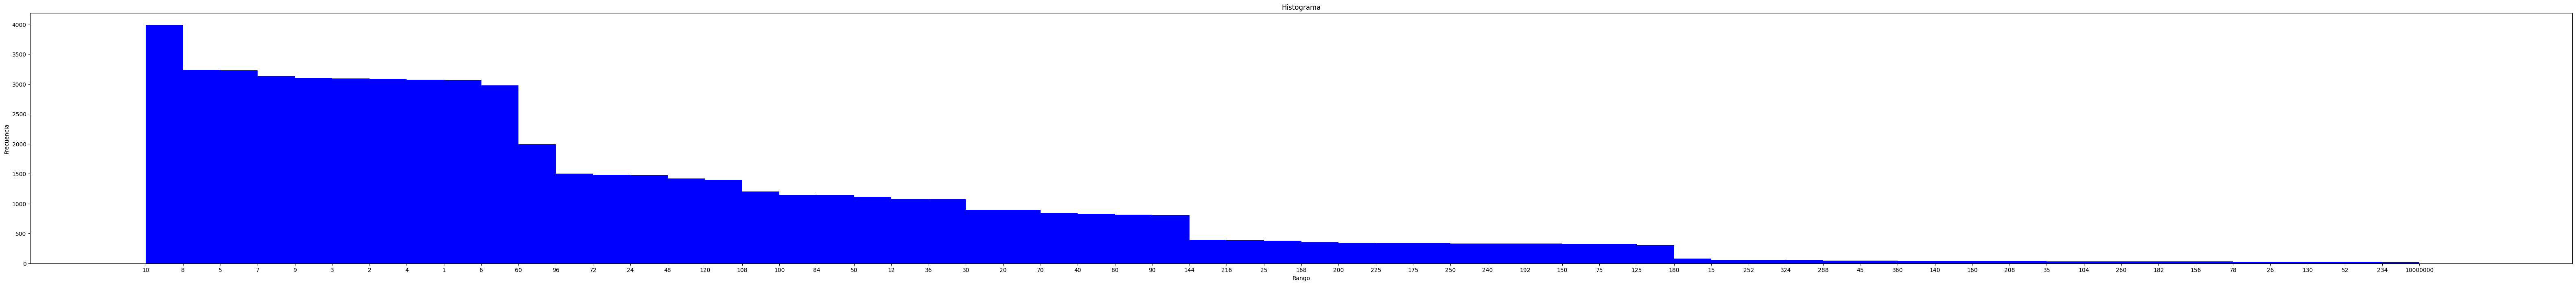

In [37]:
def plotHistogramData(data):
    binSides, binCounts = [row[0] for row in data.collect()], [row[1] for row in data.collect()]
    binSides = [round(i, 2) for i in binSides]
    N = len(binCounts)
    ind = np.arange(N)
    width = 1

    fig, ax = plt.subplots()
    rects1 = ax.bar(ind+0.5, binCounts, width, color='b')
    
    fig.set_size_inches(1.3*N, 8)

    ax.set_ylabel('Frecuencia')
    ax.set_xlabel('Rango')
    ax.set_title('Histograma')
    ax.set_xticks(np.arange(N))
    ax.set_xticklabels(binSides)

    plt.show()

plotHistogramData(cantidades)

El diagrama de dispersion, nos muestra los datos para dos variables en forma de puntos y es muy útil para entender la relación entre dichas variables

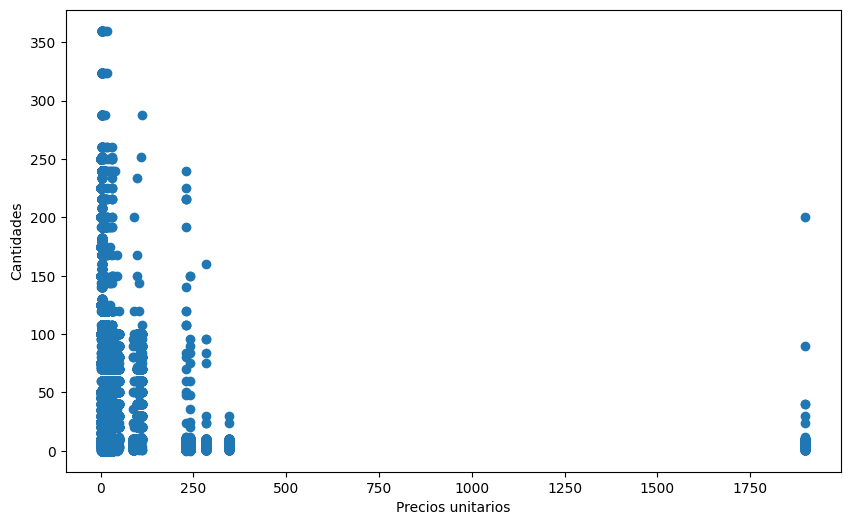

In [38]:
unitPrices = [row['Precio_unitario'] for row in detallesOrdenes.select(col('Precio_unitario')).collect()]
quantities = [row['Cantidad_seleccionada'] for row in detallesOrdenes.collect()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = unitPrices, y = quantities)
plt.xlabel("Precios unitarios")
plt.ylabel("Cantidades")

plt.show()

### Otras opciones de exploración
PySpark también da la opción de crear tablas de pivotes. En el siguiente ejemplo, se muestra cómo hacer una tabla que permite ver cuántas ordenes hay por cada <i>Fecha_de_pedido</i> y por cada <i>ID_de_vendedor</i>, es decir por fecha y por empleado cuantas ordenes existen:

In [39]:
ordenes.groupBy('Fecha_de_pedido').pivot('ID_de_vendedor').count().show()

+---------------+----+---+---+----+----+----+---+----+---+----+
|Fecha_de_pedido|   2|  3|  6|   7|   8|  13| 14|  15| 16|  20|
+---------------+----+---+---+----+----+----+---+----+---+----+
|     2014-12-13|   7|  8|  7|   5|   3|   6|  7|   6|  2|   6|
|     2014-05-27|   6|  7|  8|   6|   2|  11|  6|   5| 13|   6|
|     2014-02-22|   6|  4|  2|   6|   4|   3|  2|NULL| 11|   7|
|     2015-05-01|  22| 13| 17|   2|  14|  13|  9|  11| 19|  16|
|    Feb 27,2014|   5|  3|  6|   1|   3|NULL|  3|   3|  7|   1|
|     2015-02-09|   2| 13| 15|  18|   8|   6|  6|   7| 15|  15|
|    Sep 21,2015|   2|  6|  7|   6|   2|   2|  3|   3|  3|   2|
|     2014-07-14|  13| 10| 15|   7|   5|  13| 15|  10| 17|  12|
|    Jul 26,2014|   2|  2|  3|   3|   1|   1|  3|NULL|  1|   2|
|    May 14,2016|NULL|  3|  2|   5|   1|   4|  3|NULL|  1|   3|
|    Aug 22,2015|   1|  1|  2|   4|NULL|   2|  2|   2|  5|   1|
|     2014-12-11|  13| 18|  4|   4|   9|  10|  2|  11|  5|   2|
|     2015-02-27|  19| 14| 10|  10|  22|

Otro análisis muy útil es el de la correlación lineal entre dos variables, para ver la matriz de correlacion que mide esta dependencia o la fuerza de la relación lineal entre dos variables vamos a usar pandas, la interpretación es que si entre dos variables A y B  el valor obtenido es cercano a -1 o a 1, se interpreta como que A y B contienen la misma información y por ende no es necesario mantener ambas columnas

In [40]:
corr = detallesOrdenes.toPandas().corr(method='pearson')
corr.style.background_gradient(cmap='coolwarm')

ValueError: could not convert string to float: 'Tape dispenser (Blue)'

## Conclusiones/resultados


**Conclusiones generales:**

1. En la tabla de ordenes tenemos información **relacionada con el cliente, el empleado y con la órden**. Por otra parte, en los detalles de ordenes se tiene **información del pedido y del producto**
2. Una fila de órdenes representa la órden realizada por un cliente y atendida por un empleado. Mientras que el detalle de órden coincide con su nombre y contiene el detalle de cada producto solicitado en una órden.
3. ¿cuál es la diferencia entre cantidad y cantidad seleccionada?

**Conclusiones de reglas de negocio:**

1. La regla 1 no es completamente cierta, pues en los datos no hay ningun registro con tasa_de_impuesto de 10%, es necesario pedir aclaraciones al negocio en relación a este descubrimiento
2. La regla 2 no es cierta dado que el número de registros no parece coincidir con el número dado por el negocio, Hay 14.079 ordenes completamente repetidas y 258 registros que representan el mismo detalle de orden pero con valores distintos, los primeros se pueden eliminar, pero ¿qué deberíamos hacer con los segundos?
3. Los datos comienzan en enero 1 de 2014, sin embargo la regla 2 nos dice que debería ser desde 2013, ¿es un error o faltan datos?
4. Algunos formatos de fecha no coinciden con el dado en la regla 3, por ejemplo del atributo Fecha_de_pedido hay 20 mil registros que no tienen ese formato. En este caso el cambio de formato se puede implementar, ¿estan de acuerdo?
5. La descripcion de algunos productos es "a", ¿esto es correcto?

**Conclusiones de calidad:**

1. Las columnas Comentarios, Instrucciones_de_entrega y Comentarios_internos tienen un conteo igual a 0, es decir son columnas vacías por lo que se pueden eliminar
2. Vemos por ejemplo que el valor máximo de Cantidad indica valores anómalos o extremos, pues en su percentil 75% el valor máximo era 60, es decir, para el 75% de los datos, el valor de Cantidad no superaba el 70, pero el valor máximo es de 10 millones
3. Observamos que la columna ID_Tipo_Paquete solo toma el valor 7, que podría ser o no un error, se notifica al negocio.
4. Para las ordenes las columnas Seleccionado_por_ID_de_persona tiene 16662 vacios, ID_de_pedido_pendiente: 96905, Comentarios: 108291, Instrucciones_de_entrega: 108291, Comentarios_internos: 108291, Seleccion_completada_cuando: 5276, mientras que para los detalles de ordenes tenemos que las columnas con vacios son Precio_unitario: 7038 y Seleccion_completada_cuando: 3186.
5. Respecto a cardinalidad, solo la columna Detalle_orden_ID tiene una cardinalidad superior al 50%.
6. Como se puede observar hay una diferencia de 44.359 ordenes que no tienen detalles y hay 28.956 detalles que no tienen orden. Ninguno de los casos tiene sentido en el contexto de WideWorldImporters. ¿Tienen alguna forma de identificar cual detalle corresponde a cual orden?

**Usando herramientas:**

Seccion general del reporte:
1. Tenemos 14 variables y 88.258 registros (es decir, ordenes), de las cuales 7 son numericas, 2 categoricas, 1 booleana, 1 datetime y 3 no soportadas (la herramienta entiende tipo de variable como tipo de dato, asi que la información que nos da no es necesariamente correcta en este aspecto).

2. En los datos hay 29.3% de datos vacíos, (conclusión)

3. El archivo ocupa en memoria 7.5 MB

4. No hay registros duplicados

Sección de variables del reporte:

5. Note que para cada variable nos dan estadisticos como la media, mínimo y máximo asi como un histograma de distribución de la variable, para nuestros datos no observamos nada por fuera de lo comun. (Como valores extremos)

6. La variable ID_de_pedido tiene 61.3% de valores distintos, es decir, es una variable con alta cardinalidad. Este tipo de variables no aportan a las relaciones entre filas o columnas, por lo que suelen no ser útiles a la hora de hacer análitica.

7. La variable ID_cliente tiene solo el 0,8% de valores distintos, es decir que las ordenes que tenemos parecen ser de pocos clientes, pero que podrían ser recurrentes o fieles

8. Hay 10 empleados en los datos de ordenes

9. Seleccionado_por_ID_persona tiene 15,4% de datos vacíos, no es muy alto pero podríamos eliminarla si no es importante. Preguntar al negocio

10. ID_de_pedido_pendiente tiene un porcentaje de 89,5% de valores vacíos, es casi constante y las columnas constantes no aportan a los análisis, preguntar al negocio si hay algún inconveniente en borrar esta columna

11. Hay 1512 Fecha_de_pedido distintos, siendo el 3 de febrero del 2015 una de las fechas con más número de ordenes

12. Fecha_de_entrega_esperada y Seleccion_completada_cuando tienen alta cardinalidad

Sección de correlación:

13. Parecen haber columnas con correlaciones(Spearman) iguales a 1, esto significa que ambas columnas representan la misma información, idealmente no queremos columnas "repetidas", un ejemplo es ID_cliente y ID_de_persona_de_contacto, decidimos preguntarle al negocio si es necesario mantener ambas columnas

**Conclusiones de consultoria**

![Requerimiento](./Requerimiento.png)

Teniendo en cuenta el requerimiento de WWI, consideramos que es posible llevar a cabo una solucióon pues contamos con la información necesaria especificada en el análisis requerido, sin embargo es necesario realizar correcciones a los datos y obtener aclaraciones de parte del negocio para entender completamente la necesidad de negocio

Para comprobar su comprensión de esta sección, lo invitamos a responder la pregunta:

    ¿Qué funcionalidades de PySpark puedo utilizar para realizar el entendimiento de datos y cómo las puedo utilizar?
    
Como parte de nuestro trabajo es preveer posibles soluciones a las conclusiones de perfilamiento, por ende lo invitamos a responder:

    ¿Qué métodos podría utilizar para reemplazar los valores nulos de una columna por el promedio de la misma?

# 5. Tarea
Espacio para desarrollar la tarea propuesta 

### **Diagnóstico de Datos: movimientosCopia**
##### *Wide World Importers*

El presente diagnóstico tiene como objetivo evaluar la idoneidad de la tabla 
**movimientosCopia** como fuente de datos para el desarrollo de iniciativas 
analíticas en WWI. El análisis comprende cuatro dimensiones: diagnóstico general, 
validación de parámetros del negocio, diagnóstico de calidad de datos y 
hallazgos con recomendaciones.

### Perfilamiento de datos

El perfilamiento de datos constituye la primera fase del proceso de consultoría 
analítica. Su propósito es establecer una comprensión integral de la fuente de 
datos **movimientosCopia**, evaluando su estructura, comportamiento estadístico 
y alineación con los parámetros definidos por el negocio.

Esta sección se organiza en dos componentes:

- **1.1 Diagnóstico General de la Fuente de Datos:** Inspección de la estructura, 
  tipificación de atributos, estadísticas descriptivas y detección de valores 
  atípicos.
  
- **1.2 Validación de Parámetros del Negocio:** Contraste entre los valores 
  informados por WWI y los valores reales encontrados en la fuente, con el fin 
  de identificar brechas que puedan comprometer la integridad del análisis.

#### **1.1 Diagnóstico General de la Fuente de Datos:**

##### A. Carga e Inspección Inicial

In [41]:
# Carga de la tabla movimientosCopia
sql_movimientos = 'WWImportersTransactional.movimientosCopia'
movimientos = obtener_dataframe_de_bd(db_connection_string, sql_movimientos, db_user, db_psswd)

print("Vista previa de la fuente de datos:")
movimientos.show(5)

Vista previa de la fuente de datos:


+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+
|TransaccionProductoID|ProductoID|TipoTransaccionID|ClienteID|InvoiceID|ProveedorID|OrdenDeCompraID|FechaTransaccion|Cantidad|
+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+
|               118903|       217|               10|    476.0|  24904.0|           |               |     Apr 25,2014|   -40.0|
|               286890|       135|               10|     33.0|  60117.0|           |               |     Dec 10,2015|    -7.0|
|               285233|       111|               10|    180.0|  59768.0|           |               |     Dec 04,2015|    -2.0|
|               290145|       213|               10|     33.0|  60795.0|           |               |     Dec 23,2015|    -3.0|
|               247492|        90|               10|     55.0|  51851.0|           |               |     Jul 27

In [42]:
# Estructura y dimensiones de la fuente de datos
print(f"Total de registros: {movimientos.count():,}")
print(f"Total de atributos: {len(movimientos.columns)}")
print("\nEsquema de la tabla:")
movimientos.printSchema()

Total de registros: 204,292
Total de atributos: 9

Esquema de la tabla:
root
 |-- TransaccionProductoID: integer (nullable = true)
 |-- ProductoID: integer (nullable = true)
 |-- TipoTransaccionID: integer (nullable = true)
 |-- ClienteID: double (nullable = true)
 |-- InvoiceID: double (nullable = true)
 |-- ProveedorID: string (nullable = true)
 |-- OrdenDeCompraID: string (nullable = true)
 |-- FechaTransaccion: string (nullable = true)
 |-- Cantidad: double (nullable = true)



**Hallazgo:** La tabla cuenta con 204.292 registros distribuidos en 9 atributos. 
Se identifican inconsistencias en los tipos de dato asignados: ClienteID e 
InvoiceID están tipificados como `double` cuando su naturaleza como 
identificadores exige un tipo entero. ProveedorID y OrdenDeCompraID 
están almacenados como `string` cuando deberían ser numéricos. FechaTransaccion
está almacenada como `string`, lo que impide operaciones temporales directas.

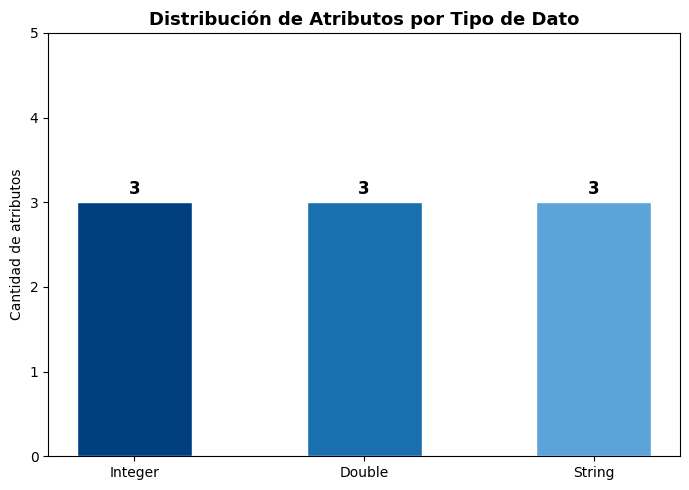

In [43]:
# Distribución de tipos de dato
import matplotlib.pyplot as plt

tipos = {'Integer': 3, 'Double': 3, 'String': 3}
colores = ['#003f7f', '#1a6faf', '#5ba3d9']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(tipos.keys(), tipos.values(), color=colores, edgecolor='white', width=0.5)
ax.set_title('Distribución de Atributos por Tipo de Dato', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de atributos')
ax.set_ylim(0, 5)
for bar, val in zip(bars, tipos.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, 
            str(val), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('tipos_dato.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** Los 9 atributos de la tabla se distribuyen equitativamente entre 
tres tipos de dato: 3 enteros (`TransaccionProductoID`, `ProductoID`, 
`TipoTransaccionID`), 3 decimales (`ClienteID`, `InvoiceID`, `Cantidad`) y 
3 cadenas de texto (`ProveedorID`, `OrdenDeCompraID`, `FechaTransaccion`). 
Se recomienda revisar la tipificación de ClienteID e InvoiceID ya que 
como identificadores no deberían admitir valores decimales.

##### B. Estadísticas Descriptivas

In [44]:
# Estadísticas descriptivas columnas numéricas
print("=== Atributos Numéricos ===")
movimientos.select("TransaccionProductoID", "ProductoID", "TipoTransaccionID",
                   "ClienteID", "InvoiceID", "Cantidad").describe().show()

print("=== Atributos Categóricos y Temporales ===")
movimientos.select("ProveedorID", "OrdenDeCompraID", "FechaTransaccion").describe().show()

=== Atributos Numéricos ===


+-------+---------------------+------------------+-------------------+------------------+-----------------+-----------------+
|summary|TransaccionProductoID|        ProductoID|  TipoTransaccionID|         ClienteID|        InvoiceID|         Cantidad|
+-------+---------------------+------------------+-------------------+------------------+-----------------+-----------------+
|  count|               204292|            204292|             204292|            204292|           204292|           204292|
|   mean|   212458.04047637695|110.70090850351458| 10.035253460732676| 517.3252941867523|42957.26929590978|719.4997650421946|
| stddev|    71352.37579752573| 63.49014746219581|0.18563716955046372|353.50136995999276| 16826.9772221931| 4729.36659747762|
|    min|                89146|                 1|                 10|               0.0|              0.0|           -360.0|
|    max|               336251|               227|                 12|            1061.0|          70510.0|          6

+-------+-----------------+------------------+--------------------+
|summary|      ProveedorID|   OrdenDeCompraID|    FechaTransaccion|
+-------+-----------------+------------------+--------------------+
|  count|           204292|            204292|              204292|
|   mean|4.951898734177215|1345.9973277074544|                NULL|
| stddev|1.406311225432683|420.37740964792835|                NULL|
|    min|                 |                  |2013-12-31 07:00:...|
|    max|              7.0|             999.0|         Sep 30,2015|
+-------+-----------------+------------------+--------------------+



**Hallazgos clave de las estadísticas descriptivas:**

- **TransaccionProductoID:** Rango entre 89.146 y 336.251, lo que sugiere que 
  la tabla es un subconjunto de una fuente mayor.
- **ProductoID:** Entre 1 y 227, consistente con un catálogo de 227 productos.
- **TipoTransaccionID:** Media de 10.03 con desviación mínima, confirmando que 
  el tipo 10 es ampliamente dominante.
- **ClienteID:** Rango entre 0 y 1.061 — el valor mínimo de 0 es un hallazgo 
  que requiere aclaración con el negocio.
- **Cantidad:** Media positiva de 719.5 pero con mínimo de -360 y máximo de 
  67.368, evidenciando alta dispersión y presencia de outliers.
- **ProveedorID y OrdenDeCompraID:** Almacenados como string pero con valores 
  numéricos. El valor mínimo vacío confirma presencia de registros sin proveedor.
- **FechaTransaccion:** El valor NULL en media confirma que no puede ser 
  procesada como fecha por su almacenamiento como string.

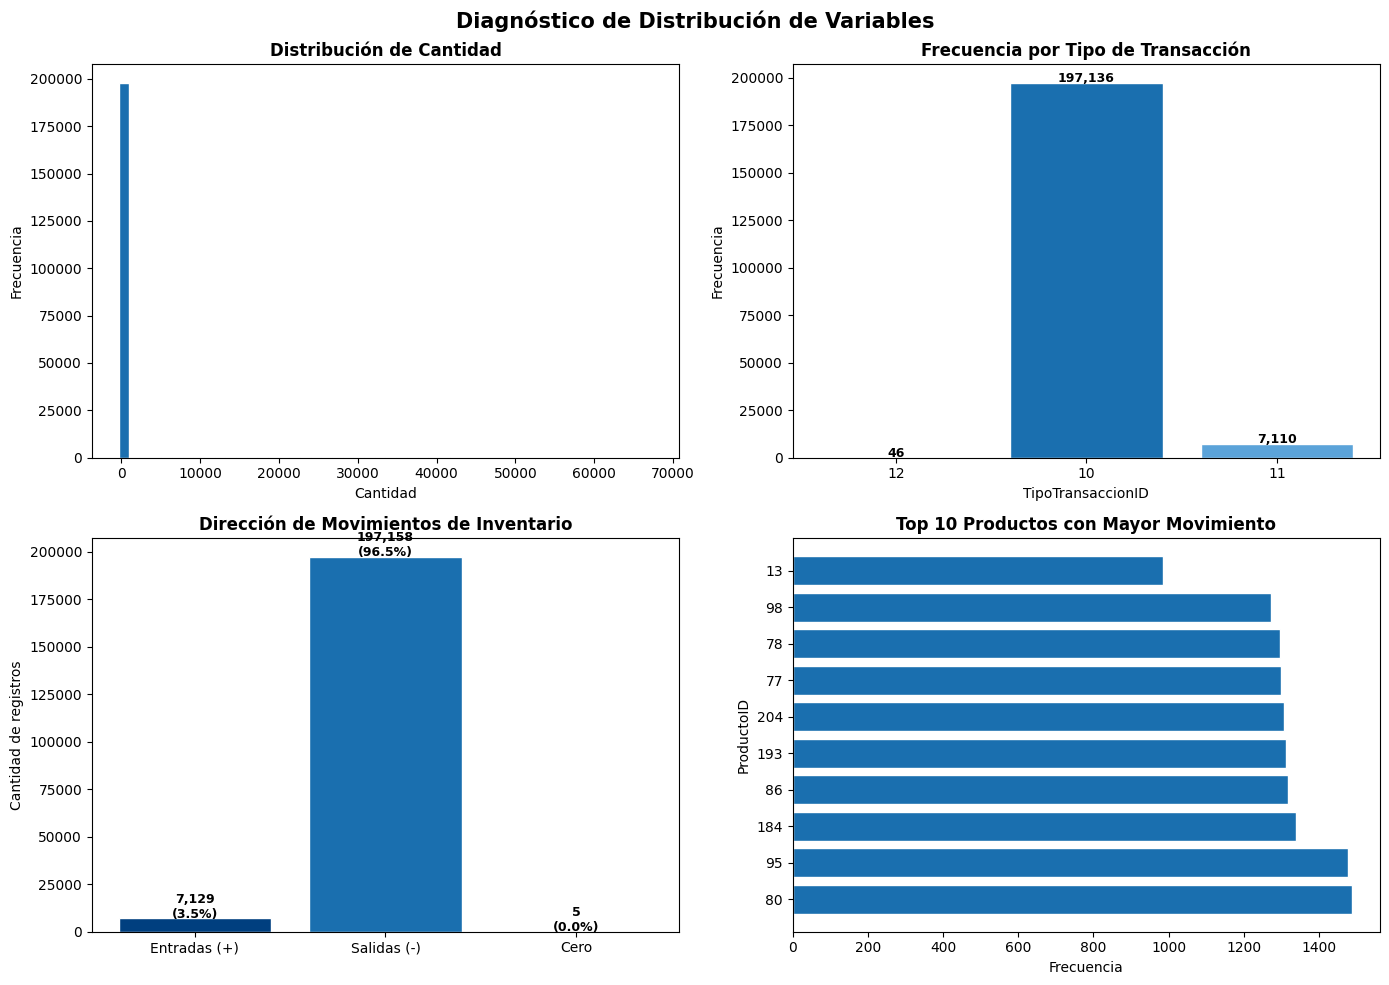

In [45]:
# Gráfica de distribución de variables clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnóstico de Distribución de Variables', fontsize=15, fontweight='bold')

paleta = ['#003f7f', '#1a6faf', '#5ba3d9', '#a8d1f0']

# 1. Distribución de Cantidad
datos_cantidad = movimientos.select("Cantidad").toPandas()
axes[0,0].hist(datos_cantidad["Cantidad"], bins=50, color='#1a6faf', edgecolor='white')
axes[0,0].set_title('Distribución de Cantidad', fontweight='bold')
axes[0,0].set_xlabel('Cantidad')
axes[0,0].set_ylabel('Frecuencia')

# 2. Distribución de TipoTransaccionID
datos_tipo = movimientos.groupBy("TipoTransaccionID").count().toPandas()
axes[0,1].bar(datos_tipo["TipoTransaccionID"].astype(str), datos_tipo["count"],
              color=paleta[:len(datos_tipo)], edgecolor='white')
axes[0,1].set_title('Frecuencia por Tipo de Transacción', fontweight='bold')
axes[0,1].set_xlabel('TipoTransaccionID')
axes[0,1].set_ylabel('Frecuencia')
for i, v in enumerate(datos_tipo["count"]):
    axes[0,1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# 3. Entradas vs Salidas
pos = movimientos.filter(col("Cantidad") > 0).count()
neg = movimientos.filter(col("Cantidad") < 0).count()
cero = movimientos.filter(col("Cantidad") == 0).count()
axes[1,0].bar(['Entradas (+)', 'Salidas (-)', 'Cero'], [pos, neg, cero],
              color=paleta[:3], edgecolor='white')
axes[1,0].set_title('Dirección de Movimientos de Inventario', fontweight='bold')
axes[1,0].set_ylabel('Cantidad de registros')
for i, v in enumerate([pos, neg, cero]):
    axes[1,0].text(i, v + 300, f'{v:,}\n({round(v/204292*100,1)}%)',
                   ha='center', fontweight='bold', fontsize=9)

# 4. Top 10 productos más movidos
datos_prod = movimientos.groupBy("ProductoID").count().orderBy("count", ascending=False).limit(10).toPandas()
axes[1,1].barh(datos_prod["ProductoID"].astype(str), datos_prod["count"],
               color='#1a6faf', edgecolor='white')
axes[1,1].set_title('Top 10 Productos con Mayor Movimiento', fontweight='bold')
axes[1,1].set_xlabel('Frecuencia')
axes[1,1].set_ylabel('ProductoID')

plt.tight_layout()
plt.savefig('distribucion_variables.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** El diagnóstico de distribución revela cuatro hallazgos estratégicos:

- **Distribución de Cantidad:** La gran mayoría de movimientos se concentran 
  cerca de cero, con una cola larga hacia valores positivos altos, evidenciando 
  la presencia de outliers que requieren investigación.
- **Tipo de Transacción:** El tipo 10 concentra el 96.5% de los movimientos, 
  siendo el tipo operativo dominante. Los tipos 11 y 12 son marginales con 
  3.5% y 0.02% respectivamente.
- **Dirección de Movimientos:** El 96.5% de los registros corresponden a 
  salidas de inventario, comportamiento consistente con una empresa distribuidora 
  cuya actividad principal es la venta de productos.
- **Productos más movidos:** Los productos 80 y 95 lideran el volumen de 
  movimientos, información relevante para la optimización del inventario.

##### C. Detección de Valores Atípicos

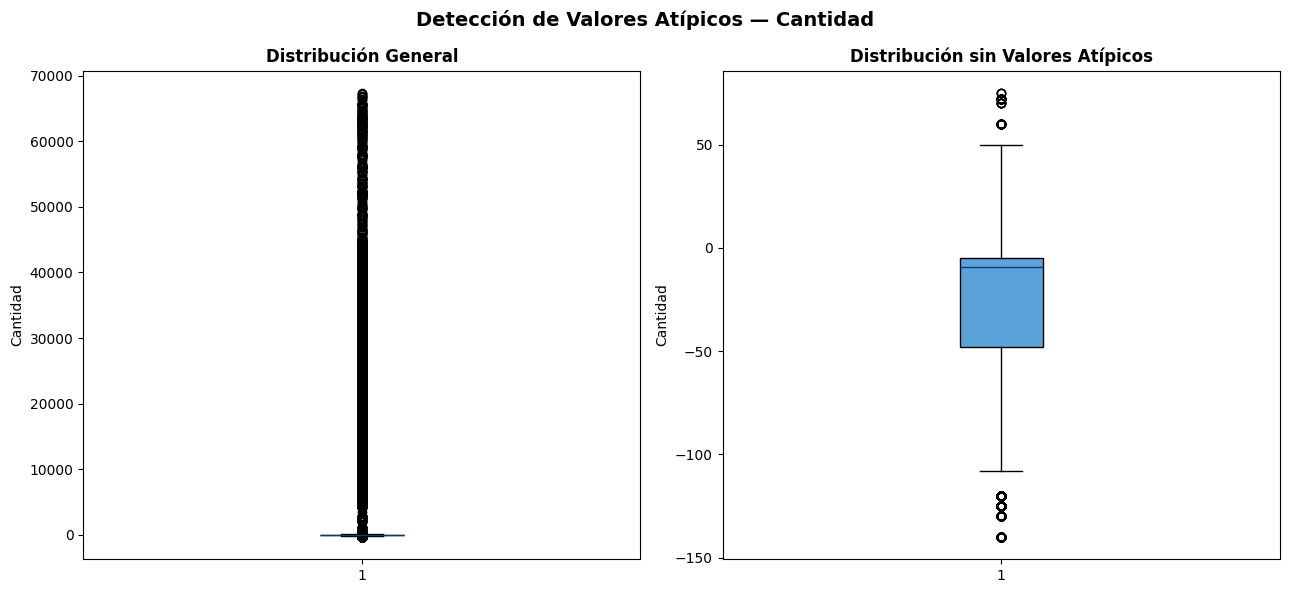

Q1: -60.0 | Q3: -5.0 | IQR: 55.0
Límite inferior: -142.5 | Límite superior: 77.5
Valores atípicos detectados: 18,789 (9.2%)


In [47]:
# Boxplot - Detección de outliers en Cantidad
datos_cantidad = movimientos.select('Cantidad').toPandas()

q1 = datos_cantidad['Cantidad'].quantile(0.25)
q3 = datos_cantidad['Cantidad'].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5*iqr
limite_sup = q3 + 1.5*iqr
sin_extremos = datos_cantidad[
    (datos_cantidad['Cantidad'] >= limite_inf) & 
    (datos_cantidad['Cantidad'] <= limite_sup)
]
outliers = len(datos_cantidad) - len(sin_extremos)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Detección de Valores Atípicos — Cantidad', fontsize=14, fontweight='bold')

bp1 = axes[0].boxplot(datos_cantidad['Cantidad'], patch_artist=True)
bp1['boxes'][0].set_facecolor('#1a6faf')
bp1['medians'][0].set_color('#003f7f')
axes[0].set_title('Distribución General', fontweight='bold')
axes[0].set_ylabel('Cantidad')

bp2 = axes[1].boxplot(sin_extremos['Cantidad'].values, patch_artist=True)
bp2['boxes'][0].set_facecolor('#5ba3d9')
bp2['medians'][0].set_color('#003f7f')
axes[1].set_title('Distribución sin Valores Atípicos', fontweight='bold')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Q1: {q1} | Q3: {q3} | IQR: {iqr}")
print(f"Límite inferior: {limite_inf} | Límite superior: {limite_sup}")
print(f"Valores atípicos detectados: {outliers:,} ({round(outliers/len(datos_cantidad)*100,1)}%)")

**Análisis:** El análisis de valores atípicos sobre la variable Cantidad revela 
una distribución con alta concentración cerca de cero y presencia significativa 
de outliers. Los hallazgos clave son:

- **Rango intercuartílico (IQR):** Los movimientos normales se ubican entre 
  -142.5 y 77.5 unidades, con una mediana negativa de -25, confirmando que 
  la operación predominante es la salida de inventario.
- **Valores atípicos:** Se detectaron **18.789 registros atípicos (9.2%)**, 
  con un valor máximo de 67.368 unidades que supera ampliamente el límite 
  superior esperado de 77.5.
- **Recomendación:** Se sugiere investigar con el negocio si estos valores 
  corresponden a operaciones legítimas de alto volumen o a errores de registro 
  antes de incluirlos en modelos analíticos.

#### **1.2 Validación de Parámetros del Negocio**

En esta sección se contrastan los parámetros informados por WWI contra los valores reales encontrados en la fuente de datos, con el fin de identificar brechas que puedan comprometer la integridad del análisis.

In [49]:
# Validación de parámetros del negocio
total = movimientos.count()

print("=== Parámetro 1: Cantidad máxima por transacción (50 millones) ===")
max_cantidad = movimientos.agg({"Cantidad": "max"}).collect()[0][0]
print(f"Valor máximo encontrado: {max_cantidad:,.0f}")
print(f"¿Cumple regla?: {'✔ SÍ' if max_cantidad <= 50000000 else '✘ NO'}")

print("\n=== Parámetro 2: Total de movimientos (236.668) ===")
print(f"Registros encontrados: {total:,}")
print(f"Registros esperados: 236,668")
print(f"Diferencia: {236668 - total:,} ({round((236668-total)/236668*100,1)}%)")

print("\n=== Parámetro 3: Clientes únicos (228.265) ===")
clientes = movimientos.select("ClienteID").distinct().count()
print(f"Clientes únicos encontrados: {clientes:,}")
print(f"Clientes esperados: 228,265")
print(f"Diferencia: {228265 - clientes:,} ({round((228265-clientes)/228265*100,1)}%)")

print("\n=== Parámetro 4: Formato de fechas (YYYY-MM-DD HH:MM:SS) ===")
movimientos.select("FechaTransaccion").show(3)

print("=== Parámetro 5: Proveedores únicos (13) ===")
proveedores = movimientos.select("ProveedorID").distinct().count()
print(f"Proveedores únicos encontrados: {proveedores - 1}")
print(f"Proveedores esperados: 13")
movimientos.groupBy("ProveedorID").count().orderBy("ProveedorID").show()

=== Parámetro 1: Cantidad máxima por transacción (50 millones) ===


Valor máximo encontrado: 67,368
¿Cumple regla?: ✔ SÍ

=== Parámetro 2: Total de movimientos (236.668) ===
Registros encontrados: 204,292
Registros esperados: 236,668
Diferencia: 32,376 (13.7%)

=== Parámetro 3: Clientes únicos (228.265) ===


Clientes únicos encontrados: 664
Clientes esperados: 228,265
Diferencia: 227,601 (99.7%)

=== Parámetro 4: Formato de fechas (YYYY-MM-DD HH:MM:SS) ===


+----------------+
|FechaTransaccion|
+----------------+
|     Apr 25,2014|
|     Dec 10,2015|
|     Dec 04,2015|
+----------------+
only showing top 3 rows

=== Parámetro 5: Proveedores únicos (13) ===


Proveedores únicos encontrados: 3
Proveedores esperados: 13


+-----------+------+
|ProveedorID| count|
+-----------+------+
|           |197182|
|        1.0|    11|
|        4.0|  4832|
|        7.0|  2267|
+-----------+------+



**Hallazgos:**

- **Parámetro 1 — Cantidad máxima:** ✔ Se cumple. El valor máximo encontrado 
  es 67.368, dentro del límite de 50 millones informado.
- **Parámetro 2 — Total movimientos:** ✘ No se cumple. Se encontraron 204.292 
  registros vs 236.668 esperados — una brecha del 13.7% (32.376 registros faltantes).
- **Parámetro 3 — Clientes únicos:** ✘ No se cumple. Se encontraron únicamente 
  664 clientes vs 228.265 esperados — una brecha crítica del 99.7%.
- **Parámetro 4 — Formato de fechas:** ✘ No se cumple. Las fechas no siguen 
  el formato YYYY-MM-DD HH:MM:SS informado por el negocio.
- **Parámetro 5 — Proveedores únicos:** ✘ No se cumple. Solo se encontraron 
  3 proveedores con datos vs 13 esperados.

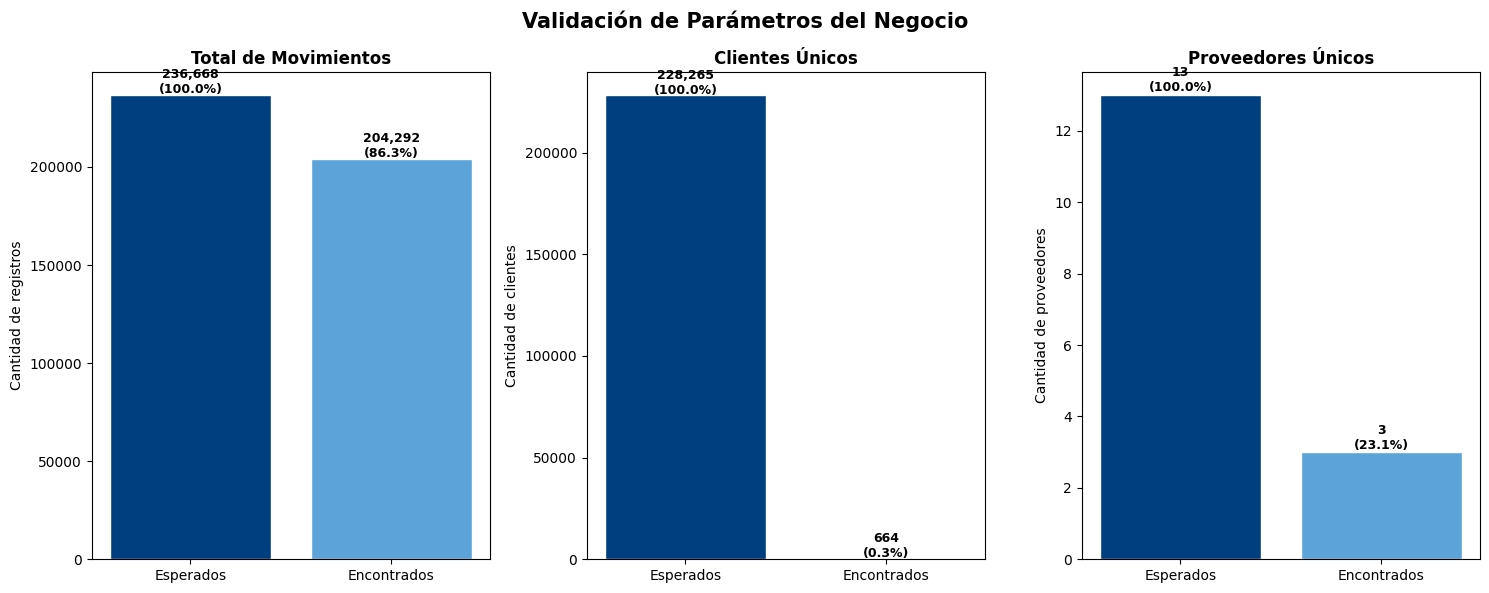

In [50]:
# Gráfica comparativa de parámetros del negocio
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Validación de Parámetros del Negocio', fontsize=15, fontweight='bold')

# Parámetro 2: Registros
axes[0].bar(['Esperados', 'Encontrados'], [236668, 204292],
            color=['#003f7f', '#5ba3d9'], edgecolor='white')
axes[0].set_title('Total de Movimientos', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate([236668, 204292]):
    axes[0].text(i, v + 1000, f'{v:,}\n({round(v/236668*100,1)}%)',
                ha='center', fontweight='bold', fontsize=9)

# Parámetro 3: Clientes
axes[1].bar(['Esperados', 'Encontrados'], [228265, 664],
            color=['#003f7f', '#5ba3d9'], edgecolor='white')
axes[1].set_title('Clientes Únicos', fontweight='bold')
axes[1].set_ylabel('Cantidad de clientes')
for i, v in enumerate([228265, 664]):
    axes[1].text(i, v + 500, f'{v:,}\n({round(v/228265*100,1)}%)',
                ha='center', fontweight='bold', fontsize=9)

# Parámetro 5: Proveedores
axes[2].bar(['Esperados', 'Encontrados'], [13, 3],
            color=['#003f7f', '#5ba3d9'], edgecolor='white')
axes[2].set_title('Proveedores Únicos', fontweight='bold')
axes[2].set_ylabel('Cantidad de proveedores')
for i, v in enumerate([13, 3]):
    axes[2].text(i, v + 0.1, f'{v}\n({round(v/13*100,1)}%)',
                ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('parametros_negocio.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** La validación de parámetros revela brechas críticas entre los 
datos informados por WWI y los datos reales de la fuente. Las tres dimensiones 
graficadas evidencian incumplimientos significativos:

- **Total de movimientos:** La fuente contiene el 86.3% de los registros 
  esperados, con una brecha de 32.376 registros que requiere explicación 
  por parte del negocio.
- **Clientes únicos:** Este es el hallazgo más crítico — solo se encontró 
  el 0.3% de los clientes esperados (664 vs 228.265). Esto sugiere que la 
  tabla compartida es un subconjunto muy reducido de la fuente original, 
  o que existe un problema estructural en el proceso de extracción de datos.
- **Proveedores únicos:** Solo el 23.1% de los proveedores esperados tienen 
  registros en la tabla, lo que limita cualquier análisis de comportamiento 
  por proveedor.

Estos hallazgos deben ser escalados al cliente como prioridad antes de 
avanzar en el desarrollo de soluciones analíticas.

### Análisis de calidad de datos

El análisis de calidad de datos tiene como objetivo evaluar la confiabilidad 
y consistencia de la fuente **movimientosCopia** a partir de cuatro dimensiones 
estándar de calidad. Los hallazgos de esta sección son determinantes para 
definir las transformaciones requeridas antes de utilizar los datos en 
iniciativas analíticas.

Las dimensiones evaluadas son:

- **2.1 Dimensión de Completitud:** Identificación de atributos con valores 
  nulos o vacíos que limiten la cobertura del análisis.

- **2.2 Dimensión de Unicidad:** Detección de registros duplicados y análisis 
  de cardinalidad por atributo.

- **2.3 Dimensión de Consistencia:** Validación de coherencia interna en 
  formatos, tipos de dato y valores esperados por el negocio.

- **2.4 Dimensión de Validez:** Verificación de que los valores se encuentren 
  dentro de los rangos y dominios permitidos según las reglas del negocio.

##### 2.1 Dimensión de Completitud
Esta dimensión evalúa la presencia de valores nulos o vacíos en cada atributo 
de la tabla. Un alto porcentaje de vacíos en un atributo compromete su 
utilidad para el análisis y puede indicar problemas en el proceso de 
captura o extracción de datos.

In [52]:
# Completitud - Nulos y vacíos por columna
from pyspark.sql.functions import isnan, when, count, col

total = movimientos.count()
print("=== Completitud por atributo ===")
for c in movimientos.columns:
    nulos = movimientos.filter(
        col(c).isNull() | (col(c).cast("string") == "")
    ).count()
    pct = round(nulos/total*100, 2)
    estado = "CRÍTICO" if pct > 50 else "ALERTA" if pct > 0 else "OK"
    print(f"{c}: {nulos:,} vacíos ({pct}%) — {estado}")

=== Completitud por atributo ===


TransaccionProductoID: 0 vacíos (0.0%) — OK


ProductoID: 0 vacíos (0.0%) — OK


TipoTransaccionID: 0 vacíos (0.0%) — OK


ClienteID: 0 vacíos (0.0%) — OK


InvoiceID: 0 vacíos (0.0%) — OK


ProveedorID: 197,182 vacíos (96.52%) — CRÍTICO


OrdenDeCompraID: 197,182 vacíos (96.52%) — CRÍTICO


FechaTransaccion: 0 vacíos (0.0%) — OK


Cantidad: 0 vacíos (0.0%) — OK


**Hallazgos:**

- **7 atributos** presentan completitud del 100% 
- **ProveedorID y OrdenDeCompraID** presentan un nivel crítico de vacíos 
  con el **96.52%** (197.182 registros), lo que los hace prácticamente 
  inutilizables para análisis sin una intervención previa de limpieza.

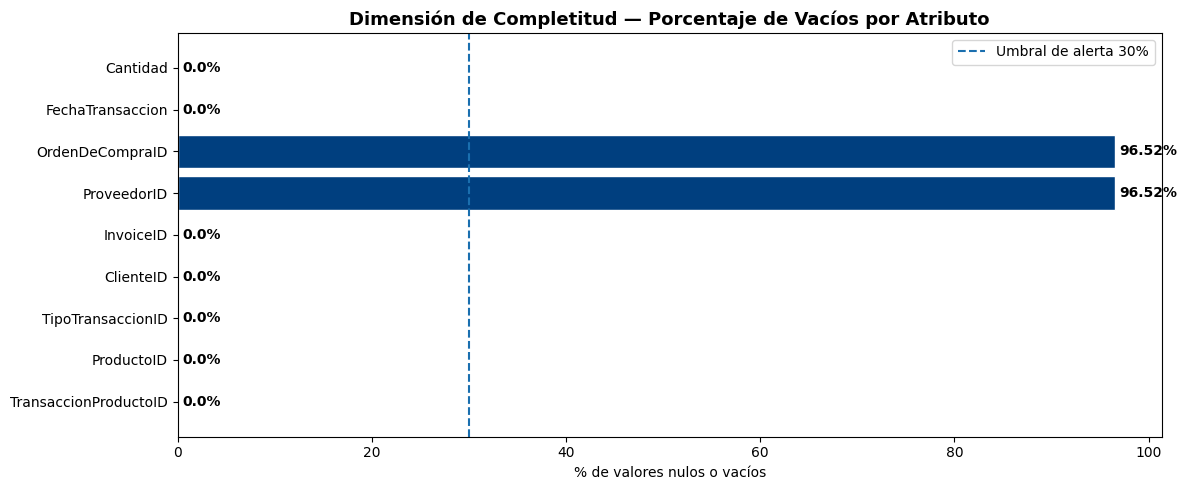

In [53]:
# Gráfica de completitud
columnas = movimientos.columns
nulos_pct = []
for c in columnas:
    nulos = movimientos.filter(
        col(c).isNull() | (col(c).cast("string") == "")
    ).count()
    nulos_pct.append(round(nulos/total*100, 2))

fig, ax = plt.subplots(figsize=(12, 5))
colores = ['#003f7f' if x > 50 else '#1a6faf' if x > 0 else '#a8d1f0' for x in nulos_pct]
bars = ax.barh(columnas, nulos_pct, color=colores, edgecolor='white')
ax.set_title('Dimensión de Completitud — Porcentaje de Vacíos por Atributo', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('% de valores nulos o vacíos')
ax.axvline(x=30, color='#1a6faf', linestyle='--', linewidth=1.5, label='Umbral de alerta 30%')
for bar, val in zip(bars, nulos_pct):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('completitud.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** La gráfica evidencia un comportamiento bimodal en la completitud 
de los atributos: 7 de los 9 atributos presentan completitud perfecta (0% de 
vacíos), mientras que **ProveedorID** y **OrdenDeCompraID** superan ampliamente 
el umbral de alerta del 30%, alcanzando un nivel crítico del 96.52%. 

Esta situación limita significativamente la capacidad de realizar análisis 
por proveedor u orden de compra. Se recomienda como acción prioritaria 
investigar con el equipo de WWI el origen de estos vacíos antes de incluir 
estos atributos en cualquier modelo analítico.

##### 2.2 Dimensión de Unicidad
Esta dimensión evalúa la existencia de registros duplicados en la tabla 
y analiza la cardinalidad de cada atributo. Un alto nivel de duplicados 
puede inflar artificialmente métricas de conteo y suma, comprometiendo 
la confiabilidad de los análisis.

In [54]:
# Unicidad - Duplicados y cardinalidad
total = movimientos.count()
unicos = movimientos.select("TransaccionProductoID").distinct().count()
duplicados = total - unicos
filas_duplicadas = total - movimientos.distinct().count()

print("=== Unicidad — Llave Primaria ===")
print(f"Total registros: {total:,}")
print(f"IDs únicos (TransaccionProductoID): {unicos:,}")
print(f"Registros duplicados: {duplicados:,} ({round(duplicados/total*100,1)}%)")
print(f"Filas completamente duplicadas: {filas_duplicadas:,}")

print("\n=== Cardinalidad por Atributo ===")
cardinalidad_data = {}
for c in movimientos.columns:
    card = movimientos.select(c).distinct().count()
    cardinalidad_data[c] = card
    pct = round(card/total*100, 2)
    print(f"{c}: {card:,} valores únicos ({pct}%)")

=== Unicidad — Llave Primaria ===
Total registros: 204,292
IDs únicos (TransaccionProductoID): 173,659
Registros duplicados: 30,633 (15.0%)
Filas completamente duplicadas: 30,633

=== Cardinalidad por Atributo ===


TransaccionProductoID: 173,659 valores únicos (85.01%)


ProductoID: 227 valores únicos (0.11%)


TipoTransaccionID: 3 valores únicos (0.0%)


ClienteID: 664 valores únicos (0.33%)


InvoiceID: 51,831 valores únicos (25.37%)


ProveedorID: 4 valores únicos (0.0%)


OrdenDeCompraID: 1,472 valores únicos (0.72%)


FechaTransaccion: 2,155 valores únicos (1.05%)


Cantidad: 3,383 valores únicos (1.66%)


**Hallazgos:**

- Se detectaron **30.633 registros duplicados (15%)** en la llave primaria 
  `TransaccionProductoID`, lo que representa un problema significativo de unicidad.
- Las filas completamente duplicadas coinciden con el mismo número (30.633), 
  confirmando que son registros idénticos en todos sus atributos.
- **TransaccionProductoID** tiene cardinalidad del 85%, confirmando su rol 
  como llave primaria aunque con duplicados.
- **InvoiceID** tiene cardinalidad media (25.37%), indicando que una factura 
  puede estar asociada a múltiples movimientos.
- Los demás atributos tienen cardinalidad baja, comportamiento esperado para 
  identificadores de categorías.

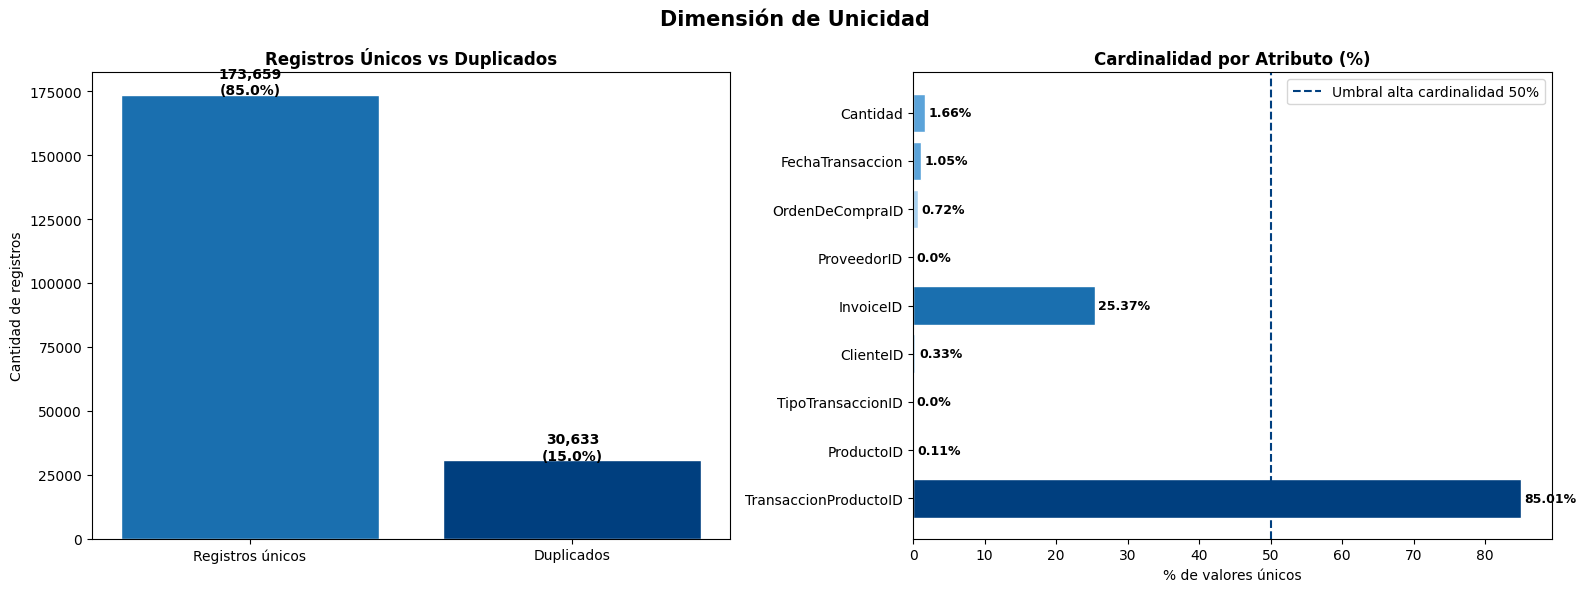

In [56]:
# Gráfica de unicidad y cardinalidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dimensión de Unicidad', fontsize=15, fontweight='bold')

# Gráfica 1: Duplicados
labels = ['Registros únicos', 'Duplicados']
valores = [173659, 30633]
colores = ['#1a6faf', '#003f7f']
axes[0].bar(labels, valores, color=colores, edgecolor='white')
axes[0].set_title('Registros Únicos vs Duplicados', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(valores):
    axes[0].text(i, v + 300, f'{v:,}\n({round(v/204292*100,1)}%)',
                ha='center', fontweight='bold', fontsize=10)

# Gráfica 2: Cardinalidad
columnas = list(cardinalidad_data.keys())
porcentajes = [round(v/total*100, 2) for v in cardinalidad_data.values()]
colores_card = ['#003f7f' if p > 50 else '#1a6faf' if p > 10 else '#5ba3d9' 
                if p > 1 else '#a8d1f0' for p in porcentajes]
bars = axes[1].barh(columnas, porcentajes, color=colores_card, edgecolor='white')
axes[1].set_title('Cardinalidad por Atributo (%)', fontweight='bold')
axes[1].set_xlabel('% de valores únicos')
axes[1].axvline(x=50, color='#003f7f', linestyle='--', 
                linewidth=1.5, label='Umbral alta cardinalidad 50%')
for bar, val in zip(bars, porcentajes):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontweight='bold', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig('unicidad.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** La dimensión de unicidad revela dos hallazgos relevantes:

- **Duplicados:** El 15% de los registros son duplicados, lo que representa 
  un riesgo alto para cualquier análisis de conteo o agregación. Se recomienda 
  aplicar `distinct()` como paso inicial del proceso de limpieza para eliminar 
  estos registros antes de cualquier transformación posterior.

- **Cardinalidad:** `TransaccionProductoID` supera el umbral del 50% con un 
  85.01%, confirmando su rol como llave primaria de la tabla. `InvoiceID` 
  presenta cardinalidad media del 25.37%, lo que indica que una factura 
  agrupa múltiples movimientos de inventario. Los demás atributos presentan 
  cardinalidad baja, comportamiento esperado para variables categóricas como 
  `TipoTransaccionID`, `ProductoID` y `ProveedorID`.

##### 2.3 Dimensión de Consistencia
Esta dimensión evalúa la coherencia interna de los datos, verificando 
que los valores sigan formatos estándar, que los tipos de dato sean 
los adecuados y que no existan valores que contradigan las reglas 
del negocio al interior de la tabla.

In [57]:
# Consistencia
total = movimientos.count()

# 1. Formato de fechas
print("=== Consistencia 1: Formatos de FechaTransaccion ===")
formato_correcto = movimientos.filter(
    col("FechaTransaccion").rlike("^\d{4}-\d{2}-\d{2}")
).count()
formato_incorrecto = movimientos.filter(
    col("FechaTransaccion").rlike("^[A-Za-z]{3}\s\d{2},\d{4}")
).count()
print(f"Formato correcto (YYYY-MM-DD): {formato_correcto:,} ({round(formato_correcto/total*100,1)}%)")
print(f"Formato incorrecto (MMM DD,YYYY): {formato_incorrecto:,} ({round(formato_incorrecto/total*100,1)}%)")

# 2. ClienteID = 0
print("\n=== Consistencia 2: ClienteID = 0 ===")
cliente_cero = movimientos.filter(col("ClienteID") == 0).count()
print(f"Registros con ClienteID = 0: {cliente_cero:,} ({round(cliente_cero/total*100,1)}%)")

# 3. Tipos de dato incorrectos
print("\n=== Consistencia 3: Atributos con tipo de dato incorrecto ===")
print("ClienteID almacenado como Double (debería ser Integer)")
print("InvoiceID almacenado como Double (debería ser Integer)")
print("ProveedorID almacenado como String (debería ser Integer)")
print("OrdenDeCompraID almacenado como String (debería ser Integer)")
print("FechaTransaccion almacenado como String (debería ser Date)")

# 4. Valores únicos ProveedorID
print("\n=== Consistencia 4: Distribución ProveedorID ===")
movimientos.groupBy("ProveedorID").count().orderBy("ProveedorID").show()

=== Consistencia 1: Formatos de FechaTransaccion ===


Formato correcto (YYYY-MM-DD): 140,038 (68.5%)
Formato incorrecto (MMM DD,YYYY): 64,254 (31.5%)

=== Consistencia 2: ClienteID = 0 ===


Registros con ClienteID = 0: 7,156 (3.5%)

=== Consistencia 3: Atributos con tipo de dato incorrecto ===
ClienteID almacenado como Double (debería ser Integer)
InvoiceID almacenado como Double (debería ser Integer)
ProveedorID almacenado como String (debería ser Integer)
OrdenDeCompraID almacenado como String (debería ser Integer)
FechaTransaccion almacenado como String (debería ser Date)

=== Consistencia 4: Distribución ProveedorID ===


+-----------+------+
|ProveedorID| count|
+-----------+------+
|           |197182|
|        1.0|    11|
|        4.0|  4832|
|        7.0|  2267|
+-----------+------+



**Hallazgos:**

- **Formato de fechas:** El 31.5% de los registros (64.254) tienen un formato 
  de fecha inconsistente (MMM DD,YYYY) respecto al estándar informado por 
  el negocio (YYYY-MM-DD HH:MM:SS).
- **ClienteID = 0:** 7.156 registros (3.5%) tienen un ClienteID de valor 0, 
  el cual no corresponde a ningún cliente válido conocido.
- **Tipos de dato:** 5 atributos presentan tipificación incorrecta, lo que 
  impide operaciones nativas de fecha, suma y agrupación eficiente.
- **ProveedorID:** Almacenado como String con valores numéricos, y el valor 
  vacío representa el 96.52% de los registros.

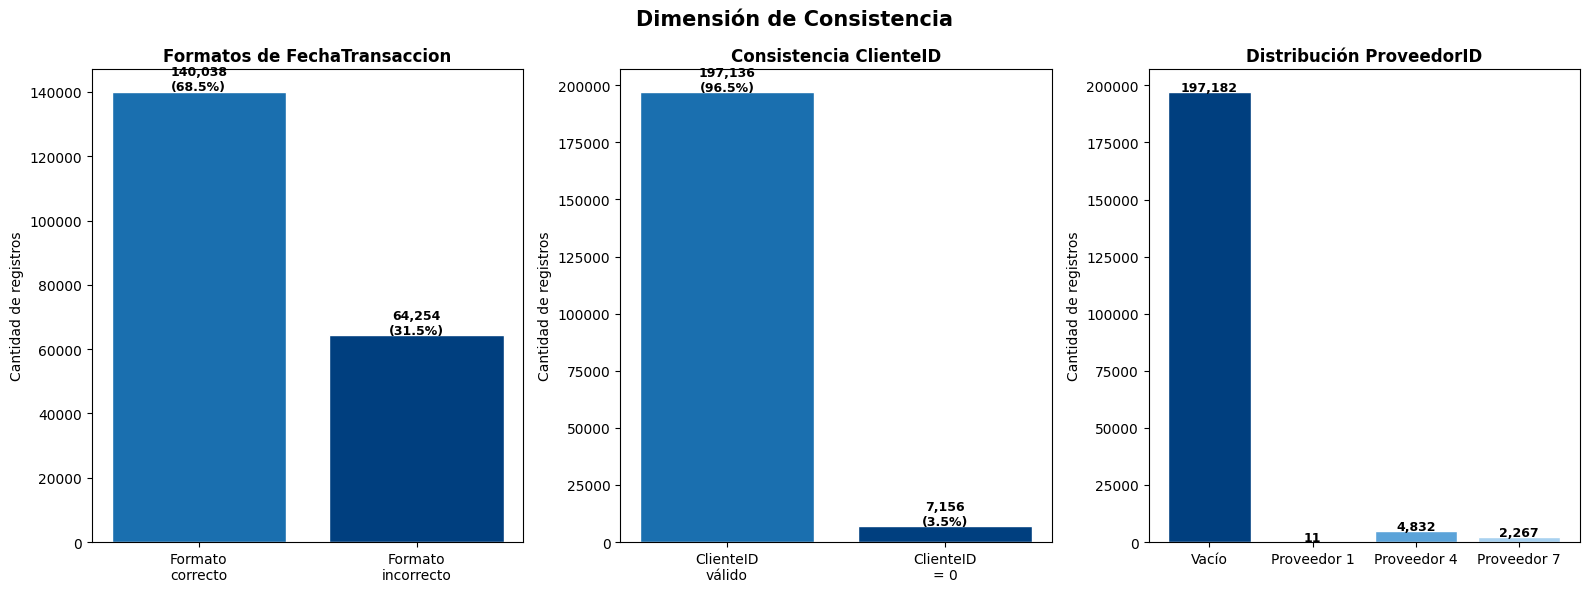

In [58]:
# Gráfica de consistencia
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Dimensión de Consistencia', fontsize=15, fontweight='bold')

# Gráfica 1: Formatos de fecha
labels_fecha = ['Formato\ncorrecto', 'Formato\nincorrecto']
valores_fecha = [140038, 64254]
colores_fecha = ['#1a6faf', '#003f7f']
axes[0].bar(labels_fecha, valores_fecha, color=colores_fecha, edgecolor='white')
axes[0].set_title('Formatos de FechaTransaccion', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(valores_fecha):
    axes[0].text(i, v + 500, f'{v:,}\n({round(v/204292*100,1)}%)',
                ha='center', fontweight='bold', fontsize=9)

# Gráfica 2: ClienteID = 0
labels_cliente = ['ClienteID\nválido', 'ClienteID\n= 0']
valores_cliente = [204292 - 7156, 7156]
colores_cliente = ['#1a6faf', '#003f7f']
axes[1].bar(labels_cliente, valores_cliente, color=colores_cliente, edgecolor='white')
axes[1].set_title('Consistencia ClienteID', fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')
for i, v in enumerate(valores_cliente):
    axes[1].text(i, v + 300, f'{v:,}\n({round(v/204292*100,1)}%)',
                ha='center', fontweight='bold', fontsize=9)

# Gráfica 3: Distribución ProveedorID
labels_prov = ['Vacío', 'Proveedor 1', 'Proveedor 4', 'Proveedor 7']
valores_prov = [197182, 11, 4832, 2267]
colores_prov = ['#003f7f', '#1a6faf', '#5ba3d9', '#a8d1f0']
axes[2].bar(labels_prov, valores_prov, color=colores_prov, edgecolor='white')
axes[2].set_title('Distribución ProveedorID', fontweight='bold')
axes[2].set_ylabel('Cantidad de registros')
for i, v in enumerate(valores_prov):
    axes[2].text(i, v + 300, f'{v:,}',
                ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('consistencia.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** La dimensión de consistencia revela tres focos de intervención:

- **Formatos de fecha:** El 31.5% de los registros presentan un formato 
  de fecha no estándar (MMM DD,YYYY), lo que impide realizar operaciones 
  temporales homogéneas sobre la tabla. Se recomienda estandarizar al 
  formato YYYY-MM-DD mediante una transformación en el proceso ETL.

- **ClienteID = 0:** El 3.5% de los registros tienen un identificador de 
  cliente inválido. Este valor puede corresponder a transacciones internas, 
  errores de captura o clientes no identificados. Se requiere aclaración 
  por parte del negocio antes de definir su tratamiento.

- **Distribución ProveedorID:** La concentración del 96.52% de registros 
  sin proveedor asignado, junto con solo 3 proveedores activos de los 13 
  esperados, sugiere que esta tabla representa únicamente las transacciones 
  de venta directa, excluyendo las transacciones de compra a proveedores.

##### 2.4 Dimensión de Validez
Esta dimensión verifica que los valores de los atributos se encuentren 
dentro de los rangos y dominios permitidos según las reglas del negocio. 
Valores fuera de rango pueden indicar errores de captura, problemas en 
el proceso de extracción o transacciones atípicas que requieren investigación.

In [59]:
# Validez
total = movimientos.count()

# 1. Cantidad fuera de rango
print("=== Validez 1: Cantidad fuera de rango (máx 50 millones) ===")
fuera_rango = movimientos.filter(col("Cantidad") > 50000000).count()
print(f"Registros con Cantidad > 50,000,000: {fuera_rango:,}")

# 2. Cantidad = 0
print("\n=== Validez 2: Movimientos con Cantidad = 0 ===")
cantidad_cero = movimientos.filter(col("Cantidad") == 0).count()
print(f"Registros con Cantidad = 0: {cantidad_cero:,} ({round(cantidad_cero/total*100,2)}%)")

# 3. TipoTransaccionID valores válidos
print("\n=== Validez 3: Distribución TipoTransaccionID ===")
movimientos.groupBy("TipoTransaccionID").count().orderBy("TipoTransaccionID").show()

# 4. ProductoID fuera de rango
print("=== Validez 4: ProductoID fuera de rango (>227) ===")
prod_fuera = movimientos.filter(col("ProductoID") > 227).count()
print(f"Registros con ProductoID > 227: {prod_fuera:,}")

# 5. Rango de Cantidad
print("\n=== Validez 5: Rango de Cantidad ===")
movimientos.select(
    f.min("Cantidad").alias("Mínimo"),
    f.max("Cantidad").alias("Máximo"),
    f.avg("Cantidad").alias("Promedio"),
    f.stddev("Cantidad").alias("Desviación estándar")
).show()

=== Validez 1: Cantidad fuera de rango (máx 50 millones) ===


Registros con Cantidad > 50,000,000: 0

=== Validez 2: Movimientos con Cantidad = 0 ===
Registros con Cantidad = 0: 5 (0.0%)

=== Validez 3: Distribución TipoTransaccionID ===


+-----------------+------+
|TipoTransaccionID| count|
+-----------------+------+
|               10|197136|
|               11|  7110|
|               12|    46|
+-----------------+------+

=== Validez 4: ProductoID fuera de rango (>227) ===


Registros con ProductoID > 227: 0

=== Validez 5: Rango de Cantidad ===


+------+-------+-----------------+-------------------+
|Mínimo| Máximo|         Promedio|Desviación estándar|
+------+-------+-----------------+-------------------+
|-360.0|67368.0|719.4997650421946|   4729.36659747762|
+------+-------+-----------------+-------------------+



**Hallazgos:**

- **Cantidad máxima:** ✔ Se cumple. Ningún registro supera el límite de 
  50 millones informado por el negocio.
- **Cantidad = 0:** Se identificaron 5 registros con Cantidad = 0, lo que 
  representa un movimiento sin impacto en el inventario y requiere aclaración.
- **TipoTransaccionID:** Los 3 valores encontrados (10, 11, 12) parecen 
  válidos, sin embargo el negocio no informó el dominio esperado para 
  este atributo — se requiere validación.
- **ProductoID:** ✔ Se cumple. Todos los productos están dentro del rango 
  esperado (1-227).
- **Rango de Cantidad:** La desviación estándar de 4.729 frente a un 
  promedio de 719 evidencia alta dispersión, con valores extremos entre 
  -360 y 67.368 que requieren investigación.

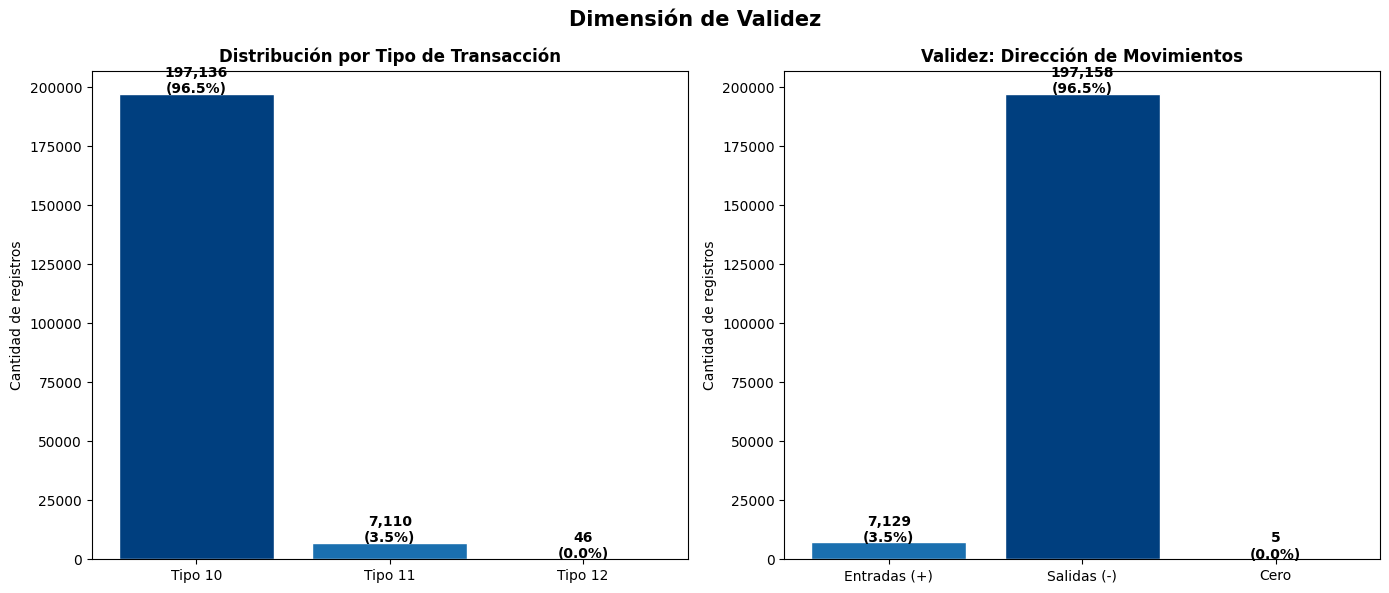

In [61]:
# Gráfica de validez
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Dimensión de Validez', fontsize=15, fontweight='bold')

# Gráfica 1: Distribución TipoTransaccionID
labels_tipo = ['Tipo 10', 'Tipo 11', 'Tipo 12']
valores_tipo = [197136, 7110, 46]
colores_tipo = ['#003f7f', '#1a6faf', '#5ba3d9']
axes[0].bar(labels_tipo, valores_tipo, color=colores_tipo, edgecolor='white')
axes[0].set_title('Distribución por Tipo de Transacción', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(valores_tipo):
    axes[0].text(i, v + 300, f'{v:,}\n({round(v/204292*100,1)}%)',
                ha='center', fontweight='bold', fontsize=10)

# Gráfica 2: Dirección de movimientos
pos = movimientos.filter(col("Cantidad") > 0).count()
neg = movimientos.filter(col("Cantidad") < 0).count()
cero = movimientos.filter(col("Cantidad") == 0).count()
labels_dir = ['Entradas (+)', 'Salidas (-)', 'Cero']
valores_dir = [pos, neg, cero]
colores_dir = ['#1a6faf', '#003f7f', '#5ba3d9']
axes[1].bar(labels_dir, valores_dir, color=colores_dir, edgecolor='white')
axes[1].set_title('Validez: Dirección de Movimientos', fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')
for i, v in enumerate(valores_dir):
    axes[1].text(i, v + 300, f'{v:,}\n({round(v/204292*100,1)}%)',
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('validez.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis:** La dimensión de validez muestra un comportamiento mayormente 
aceptable en los rangos de los atributos, con dos observaciones relevantes:

- **Tipo de Transacción:** El dominio se concentra en el Tipo 10 con el 
  96.5% de los registros, seguido del Tipo 11 con 3.5% y el Tipo 12 con 
  apenas el 0.02%. Esta distribución sugiere que los tipos 11 y 12 
  representan transacciones excepcionales cuya naturaleza debe ser 
  aclarada con el negocio para determinar si corresponden a devoluciones, 
  ajustes o correcciones de inventario.

- **Dirección de movimientos:** El 96.5% de los registros corresponden 
  a salidas de inventario, comportamiento consistente con una empresa 
  distribuidora cuya actividad principal es la venta. Las entradas (3.5%) 
  probablemente corresponden a reposición de stock o devoluciones de clientes.
  Los 5 registros con Cantidad = 0 no tienen impacto operativo pero 
  deben ser investigados antes de incluirlos en modelos analíticos.

### Conclusiones

Esta sección consolida los principales hallazgos identificados durante 
el proceso de diagnóstico de la fuente **movimientosCopia**, y presenta 
las recomendaciones estratégicas y operativas para garantizar la 
confiabilidad de los datos antes de su uso en iniciativas analíticas.

### 3.1 Significado de una Fila

Un registro de la tabla **movimientosCopia** representa un **movimiento 
de inventario** de un producto específico en una fecha determinada. 
Dicho movimiento puede corresponder a una salida de inventario 
(cantidad negativa), asociada a una venta a un cliente, o a una entrada 
(cantidad positiva), asociada a una reposición de stock. Cada registro 
está caracterizado por el tipo de transacción ejecutada, la factura 
relacionada y, cuando aplica, el proveedor y la orden de compra asociada.

La fila promedio de los datos analizados representa una **salida de 
inventario** de aproximadamente **25 unidades** de un producto del 
catálogo de WWI, ejecutada bajo el **TipoTransaccionID 10**, asociada 
a un cliente válido y una factura, sin información de proveedor ni 
orden de compra registrada.

### 3.2 Síntesis de Hallazgos

La siguiente tabla consolida los hallazgos identificados durante el 
diagnóstico, clasificados por dimensión, severidad e impacto analítico:

| Dimensión | Hallazgo | Severidad | Impacto |
|-----------|----------|-----------|---------|
| Perfilamiento | Faltan 32.376 registros vs 236.668 esperados | Alta | Subestimación de métricas |
| Perfilamiento | Solo 664 clientes vs 228.265 esperados | Alta | Análisis por cliente inviable |
| Perfilamiento | Solo 3 proveedores vs 13 esperados | Alta | Análisis por proveedor inviable |
| Completitud | ProveedorID y OrdenDeCompraID con 96.52% vacíos | Alta | Atributos inutilizables |
| Unicidad | 30.633 registros duplicados (15%) | Alta | Inflación de métricas |
| Consistencia | 31.5% fechas con formato incorrecto | Media | Operaciones temporales bloqueadas |
| Consistencia | 7.156 registros con ClienteID = 0 | Media | Transacciones no atribuibles |
| Consistencia | 5 atributos con tipo de dato incorrecto | Media | Operaciones nativas bloqueadas |
| Validez | 18.789 outliers en Cantidad (9.2%) | Media | Distorsión en agregaciones |
| Validez | 5 registros con Cantidad = 0 | Baja | Impacto mínimo |

### 3.3 Justificación para Tablero de Control

El requerimiento analítico de WWI contempla la construcción de tableros 
de control para visualizar la cantidad de productos vendidos y el valor 
total recaudado en un rango de fechas, segmentado por cliente, vendedor, 
ciudad y producto.

Con base en el diagnóstico realizado, se concluye que la tabla 
**movimientosCopia en su estado actual no es suficiente** para satisfacer 
completamente este requerimiento, por las siguientes razones:

- **Viable:** Es posible analizar movimientos por producto y por fecha, 
  dado que `ProductoID` y `FechaTransaccion` tienen completitud del 100% 
  y valores dentro del rango esperado.

- **Limitado:** El análisis por cliente es posible pero limitado, ya que 
  solo se dispone de 664 clientes únicos vs 228.265 esperados, y 7.156 
  registros tienen ClienteID = 0.

- **No viable:** No es posible realizar análisis por vendedor ni por ciudad, 
  dado que estos atributos no están presentes en la tabla compartida. 
  Adicionalmente, el análisis por proveedor es inviable dado que el 96.52% 
  de los registros no tienen proveedor asignado.

Se recomienda solicitar al cliente las tablas complementarias de clientes, 
vendedores y ciudades antes de iniciar el desarrollo del tablero de control.

### 3.4 Aclaraciones Requeridas al Cliente

Con base en los hallazgos del diagnóstico, se eleva al equipo de WWI 
la siguiente lista de aclaraciones previas al inicio del desarrollo 
de soluciones analíticas:

**Sobre la integridad de los datos:**
1. ¿Por qué la tabla contiene 204.292 registros cuando se informaron 
   236.668 movimientos desde 2013? ¿Existe un criterio de filtrado 
   aplicado en la extracción?
2. ¿Por qué solo se identificaron 664 clientes únicos cuando se 
   informaron 228.265 clientes relacionados con movimientos?
3. ¿Los 30.633 registros duplicados corresponden a movimientos 
   reales o son errores del proceso de extracción de datos?

**Sobre atributos específicos:**
4. ¿Qué representa un registro con ClienteID = 0? ¿Corresponde 
   a transacciones internas, clientes anónimos o errores de captura?
5. ¿Por qué ProveedorID y OrdenDeCompraID están vacíos en el 96.52% 
   de los registros? ¿Esta tabla excluye las transacciones de compra?
6. ¿Por qué solo aparecen 3 proveedores activos (1, 4 y 7) cuando 
   se informaron 13 proveedores en total?
7. ¿Qué origen tienen los dos formatos de fecha distintos encontrados 
   en FechaTransaccion (YYYY-MM-DD y MMM DD,YYYY)?
8. ¿Qué representa un movimiento con Cantidad = 0? ¿Es una 
   cancelación, un ajuste o un error de registro?
9. ¿Qué tipos de transacción corresponden a los IDs 10, 11 y 12? 
   ¿Existen otros tipos no presentes en esta tabla?

**Sobre fuentes complementarias:**
10. ¿Es posible obtener las tablas de clientes, vendedores y ciudades 
    para complementar el análisis requerido en el tablero de control?

### 3.5 Plan de Acción y Mejora de Datos

A continuación se presenta el plan de acción recomendado para la 
limpieza y preparación de la fuente **movimientosCopia**, ordenado 
por prioridad de intervención:

**Prioridad Alta — Intervención inmediata:**

1. *Eliminación de duplicados:* Aplicar `distinct()` sobre la tabla 
   completa para eliminar los 30.633 registros duplicados antes de 
   cualquier transformación posterior.

2. *Investigación de brechas:* Escalar al cliente la diferencia de 
   32.376 registros faltantes y la discrepancia en clientes únicos 
   antes de avanzar en el desarrollo analítico.

**Prioridad Media — Transformaciones ETL:**

3. *Estandarización de fechas:* Aplicar `to_date()` con múltiples 
   formatos de entrada para unificar `FechaTransaccion` al estándar 
   YYYY-MM-DD:
```python
   from pyspark.sql.functions import to_date, coalesce
   movimientos = movimientos.withColumn("FechaTransaccion",
       coalesce(
           to_date(col("FechaTransaccion"), "yyyy-MM-dd"),
           to_date(col("FechaTransaccion"), "MMM dd,yyyy")
       )
   )
```

4. *Corrección de tipos de dato:* Convertir `ClienteID`, `InvoiceID`, 
   `ProveedorID` y `OrdenDeCompraID` a tipo entero, y `FechaTransaccion` 
   a tipo fecha.

5. *Tratamiento de ClienteID = 0:* Reemplazar por nulo explícito 
   pendiente aclaración del negocio:
```python
   movimientos = movimientos.withColumn("ClienteID",
       when(col("ClienteID") == 0, None).otherwise(col("ClienteID"))
   )
```

**Prioridad Baja — Revisión puntual:**

6. *Registros con Cantidad = 0:* Investigar los 5 registros e 
   incorporar regla de validación en el proceso ETL.

7. *Outliers en Cantidad:* Investigar los 18.789 registros atípicos 
   con el negocio antes de decidir su exclusión o tratamiento especial.

## Cierre

Completado este tutorial ya sabrá la forma básica de utilizar PySpark. Ya sabe cómo crear DataFrames a partir de datos existentes, cómo seleccionar columnas o filas de este Dataframe, cómo rellenar espacios vacíos, cómo aplicar sus propias funciones a estos datos y los más importante, cómo utilizarlo para realizar una fase de entendimiento de datos.

Las tablas detallesOrdenesCopia y OrdenesCopia estaran disponibles en caso de que desee repetir este tutorial cuantas veces considere necesario

## 7. Información adicional

Si quiere conocer más sobre PySpark la guía más detallada es la documentación oficial, la cual puede encontrar acá: https://spark.apache.org/docs/latest/api/python/index.html <br>
Para ir directamente a la documentación de PySpark SQL, donde está la información sobre los DataFrames: https://spark.apache.org/docs/latest/api/python/pyspark.sql.html <br>

El Capítulo 2 del libro <i>Learn PySpark : Build Python-based Machine Learning and Deep Learning Models, New York: Apress. 2019</i> de Pramod Singh contiene muchos ejemplos útiles, puede encontrarlo en la biblioteca virtual de la universidad.

## 8. Preguntas frecuentes

1. Si en el cálculo de los histogramas o en una de sus UDF obtiene el error: TypeError: unsupported operand type(s) for *: 'decimal.Decimal' and 'float' verifique los tipos de las columnas que está intentando operar y, si alguna es double, conviértala a float.

2. En algunos casos, encontrará también información sobre <i>Pandas_UDF</i>. <i>Pandas_UDF</i> son también User Defined Functions, por lo general los Pandas UDF son más eficientes que los UDF tradicionales, sin embargo, hay un bug con la versión de PySpark y de Java que se está usando, lo que previene la utilización de Pandas_UDF.

3. Si al ejecutar la configuración de la sesión Spark le aparece el error <i>Cannot run multiple SparkContexts at once; existing SparkContext(app=pyspark-shell, master=local[*])</i> Reinicie el kernel y vuelva a ejecutar
